# Delivery Dron. Команда 15

> Подготовили: Нигматуллин Рамис, Семенова Валерия, Шаститко Мирослав

### Цель:
> Выяснить, в какой регион и какой рекламный канал инвестировать больше денег на привлечение клиентов в следующем году (с обоснованием своего предложения)

#### Описание данных

Файл ecom_yl.csv содержит данные о визитах и покупках пользователей сайта интернет магазина “Delivery Dron”. Каждая строка представляет визит пользователя. Данные отсортированы по Session Date.

**Столбцы набора данных:**

0: User Id - id пользователя

1: Region - регион визита

2: Device - устройство, с которого производится вход на сайт

3: Channel - рекламный канал перехода на сайт

4: Session Start - время начала пользовательской сессии (входа на сайт)

5: Session End - время окончания пользовательской сессии (уход с сайта)

6: SessionDurationSec - длительность сессии в секундах

7: Session Date - дата визита

8: Month - месяц визита

9: Day - день дня недели визита

10: Hour of day - час (от 0 до 24) визита

11: Order Dt - дата покупки

12: Revenue - сумма покупки

13: Payment Type - тип оплаты

14: Promo code - использование промокода на скидку 10% (есть-1, нет-0).

## 0. Импорт библиотек

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

In [1]:
import pandas as pd
import numpy as np
from math import ceil
from scipy import stats

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
import warnings

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [4]:
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

In [5]:
%matplotlib inline

In [6]:
pd.set_option('display.width', 150)

## 1. Чтение исходного файла

In [ ]:
# Путь к исходному файлу с данными
csv_path = os.getenv('DATA_PATH')

In [9]:
date_columns = ['Session Start', 'Session End', 'Session Date', 'Order Dt']

In [10]:
df = pd.read_csv(
    csv_path,
    sep=';',
    parse_dates=date_columns, # перевод столбцов в формат даты
    na_values={' ': None}
)

# приведение названия столбцов к PEP8
df.columns = df.columns.str.lower().str.replace(' ', '_')

## 2. Предобработка данных

Включает в себя просмотр общей информации признаков и их типах, работа с пропусками, дубликатами и выбросами, создание новых признаков, а также поиск мультиколлинеарных признаков.

### 2.1. Общая информация

In [11]:
df.shape

(1012, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             1012 non-null   int64         
 1   region              999 non-null    object        
 2   device              999 non-null    object        
 3   channel             999 non-null    object        
 4   session_start       1012 non-null   datetime64[ns]
 5   session_end         1012 non-null   datetime64[ns]
 6   sessiondurationsec  1012 non-null   float64       
 7   session_date        1012 non-null   datetime64[ns]
 8   month               1012 non-null   int64         
 9   day                 1012 non-null   int64         
 10  hour_of_day         1012 non-null   int64         
 11  order_dt            285 non-null    datetime64[ns]
 12  revenue             285 non-null    float64       
 13  payment_type        285 non-null    object      

In [13]:
df.head()

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaT,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.000000,2025-05-01,5,3,4,NaT,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.000000,2025-05-01,5,3,18,NaT,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.000000,2025-05-02,5,4,14,NaT,NaN,NaN,NaN


In [14]:
df.rename(columns={'sessiondurationsec': 'session_duration_sec'}, inplace=True)

df.head()

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaT,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.000000,2025-05-01,5,3,4,NaT,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.000000,2025-05-01,5,3,18,NaT,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.000000,2025-05-02,5,4,14,NaT,NaN,NaN,NaN


### 2.2. Просмотр категориальных данных и их наименований

In [15]:
# столбцы с категориальным типом данных
obj_columns = df.select_dtypes(include=[object]).columns


# узнаем, какие есть значения и нет ли опечаток
for col_name in obj_columns:
  print(df[col_name].value_counts())
  print('-'*40)

region
United States    535
Unjted States    144
UK               111
Germany           89
France            52
Frаnce            32
germany           13
Frаncе            10
Franсe             9
UК                 4
Name: count, dtype: int64
----------------------------------------
device
iPhone     356
Android    223
PC         206
Mac        201
android     13
Name: count, dtype: int64
----------------------------------------
channel
социальные сети        370
organic                346
контекстная реклама    150
реклама у блогеров     101
email-рассылки          23
контексная реклама       9
Name: count, dtype: int64
----------------------------------------
payment_type
Mobile payments    87
E-wallet           66
Cash               62
Debit card         36
Credit card        34
Name: count, dtype: int64
----------------------------------------


In [16]:
# словари, в ключе которых указаны неправильные значения, а в значениях - правильные
mapping_region = {
    'Unjted States': 'United States',
    'UК': 'UK',
    'germany': 'Germany',
    'Frаnce': 'France',
    'Frаncе': 'France',
    'Franсe': 'France'
}

mapping_device = {'android': 'Android'}
mapping_channel = {'контексная реклама': 'контекстная реклама'}

# замена значений
df['region'] = df['region'].replace(mapping_region)
df['device'] = df['device'].replace(mapping_device)
df['channel'] = df['channel'].replace(mapping_channel)

In [17]:
# повторная проверка
for col_name in obj_columns:
  print(df[col_name].value_counts())
  print('-'*40)

region
United States    679
UK               115
France           103
Germany          102
Name: count, dtype: int64
----------------------------------------
device
iPhone     356
Android    236
PC         206
Mac        201
Name: count, dtype: int64
----------------------------------------
channel
социальные сети        370
organic                346
контекстная реклама    159
реклама у блогеров     101
email-рассылки          23
Name: count, dtype: int64
----------------------------------------
payment_type
Mobile payments    87
E-wallet           66
Cash               62
Debit card         36
Credit card        34
Name: count, dtype: int64
----------------------------------------


Также у нас есть столбец, в котором используются обозначения 1 и 0 - "promo_code". Посмотрим и на него

In [18]:
df['promo_code'].unique()

array([0.        ,        nan, 1.        , 0.86271506])

> У нас есть значения, которые не должны фигурировать. Заменим их на 1

In [19]:
df.loc[(df['promo_code'] < 1) & (df['promo_code'] > 0), 'promo_code'] = 1

### 2.3. Пропуски: нахождение и их обработка

Столбцы, в которых отсутствуют данные: region, device, channel, order_dt, revenue, payment_type, promo_code.

In [20]:
null_df = df.isna().sum()
null_df.loc[null_df > 0]

,0
region,13
device,13
channel,13
order_dt,727
revenue,727
payment_type,727
promo_code,727


In [21]:
# процентное соотношение
(df.isna().mean()*100).to_frame()

,0
user_id,0.000000
region,1.284585
device,1.284585
channel,1.284585
session_start,0.000000
session_end,0.000000
session_duration_sec,0.000000
session_date,0.000000
month,0.000000
day,0.000000


Возможные причины наличия пропусков и нужна ли их обработка:
- order_dt, revenue, payment_type, promo_code
  - Только часть пользователей, заходивших на сайт, совершала покупки, поэтому пропуск означает то, что данный пользователь не совершил покупку во время захода на сайт;
  - Не требуют заполнения. Лучше сделать столбец, обозначающий, сделал ли пользователь заказ ('payer').
- region, device, channel
  - Вероятно произошёл программный сбой, или же пользователь поставил ограничения на сбор данных;
  - Необходимо заполнение.

Возможные способы для заполнения данных:
1. Найти пользователей с таким же user_id. Если присутствуют несколько заполненных строк, то заполняем либо последними актуальными данными (пустое значение находится в конце или же между разными типами данных), либо определёнными значениями (пустое значение находится между строк с одинаковыми данными или же существует только одно значение).
2. Нахождение схожих user_id.
3. Выбрать наиболее встречаемые варианты.


In [22]:
# наименование колонок, которые не содержат данных о заказе
columns_withour_order = df.columns[:-4]

# маска с пропусками в колонках
mask = df[columns_withour_order].isna().any(axis=1)

# посмотрим на то, какие данные отсутствуют
df[mask]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
303,434852403169,NaN,NaN,NaN,2025-07-01 07:36:39,2025-07-01 07:52:15,936.000000,2025-07-01,7,1,7,2025-07-01 07:36:46,"4,999.000000",Debit card,1.000000
392,213468351687,NaN,NaN,NaN,2025-07-20 21:19:14,2025-07-20 21:32:09,775.000000,2025-07-20,7,6,21,NaT,NaN,NaN,NaN
429,679176482300,NaN,NaN,NaN,2025-07-28 02:19:45,2025-07-28 03:04:59,"2,714.000000",2025-07-28,7,7,3,NaT,NaN,NaN,NaN
547,87458247642,NaN,NaN,NaN,2025-08-16 17:33:09,2025-08-16 18:02:53,"1,784.000000",2025-08-16,8,5,18,2025-08-16 17:33:25,"4,999.000000",Credit card,0.000000
549,588840798518,NaN,NaN,NaN,2025-08-16 16:46:22,2025-08-16 17:34:45,"2,903.000000",2025-08-16,8,5,17,2025-08-16 16:47:07,"4,999.000000",E-wallet,0.000000
564,61219447121,NaN,NaN,NaN,2025-08-18 08:16:27,2025-08-18 08:28:59,752.000000,2025-08-18,8,7,8,2025-08-18 08:16:33,"4,999.000000",Cash,0.000000
599,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,"1,299.000000",2025-08-25,8,7,13,2025-08-25 13:21:55,"4,999.000000",Cash,1.000000
600,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,"1,299.000000",2025-08-25,8,7,13,2025-08-25 13:21:55,"4,999.000000",Cash,1.000000
652,427486793654,NaN,NaN,NaN,2025-09-03 06:02:54,2025-09-03 07:00:02,"3,428.000000",2025-09-03,9,2,7,2025-09-03 06:03:39,"4,999.000000",Debit card,1.000000
686,632186207840,NaN,NaN,NaN,2025-09-10 07:21:58,2025-09-10 07:45:43,"1,425.000000",2025-09-10,9,2,7,NaT,NaN,NaN,NaN


In [23]:
df.order_dt.notna().sum()

np.int64(285)

> 8 из 13 строк с пропущенными данными (всего 1012) является покупателями (всего 285), поэтому удаление не приемлемо

In [24]:
# попробуем 1-й способ: нахождение записей с таким же user_id
def identify_nan_values(df, nan_values, column_name='user_id'):
  res = []
  for value in nan_values:
    res_value = {
        'id': value
    }
    # выбираем только те строки, у которых определённый user_id
    data = df.loc[df[column_name] == value]

    # считаем общее количество для того, чтобы понять,
    # есть ли у нас пользователи с заполненными данными
    res_value['total'] = data.shape[0]
    res_value['nan'] = data.isna().any(axis=1).sum().item()
    res.append(res_value)
  return res


# user_id, у которых отсутствуют данные
nan_user_id = set(df.loc[df[columns_withour_order].isna().any(axis=1), 'user_id'])

search_res = identify_nan_values(df[columns_withour_order], nan_user_id)

In [25]:
search_res

[{'id': 632186207840, 'total': 2, 'nan': 1},
 {'id': 434852403169, 'total': 2, 'nan': 1},
 {'id': 634503344070, 'total': 2, 'nan': 1},
 {'id': 213468351687, 'total': 2, 'nan': 1},
 {'id': 16254498222, 'total': 2, 'nan': 2},
 {'id': 375373200590, 'total': 2, 'nan': 1},
 {'id': 61219447121, 'total': 2, 'nan': 1},
 {'id': 588840798518, 'total': 2, 'nan': 1},
 {'id': 427486793654, 'total': 2, 'nan': 1},
 {'id': 87458247642, 'total': 2, 'nan': 1},
 {'id': 679176482300, 'total': 2, 'nan': 1},
 {'id': 825998445466, 'total': 2, 'nan': 1}]

> Как можно увидеть, только для одного пользователя нет других строк данных, поэтому заполним другие найденными данными

In [26]:
def replace_values_for_user(
    df, user_id, columns_withour_order,
    column_name='user_id',
    columns=['region', 'device', 'channel'],
):
  data = df[columns_withour_order].loc[df[column_name] == user_id]
  nan_mask = data.isna().any(axis=1)
  if data.shape[0] == nan_mask.sum().item() or nan_mask.shape[0] == 0:
    return df

  # берём только первые индексы, потому что знаем, что всего два значения
  # где одно с NaN, а второе - с заполненными
  index = nan_mask.loc[nan_mask == False].index[0]
  index_to_replace = nan_mask.loc[nan_mask == True].index[0]

  if not isinstance(index, int):
    index = index.item()

  if not isinstance(index_to_replace, int):
    index_to_replace = index_to_replace.item()

  df.loc[index_to_replace, columns] = df.loc[index, columns]

  return df

In [27]:
for user_id in nan_user_id:
  df = replace_values_for_user(df, user_id, columns_withour_order)

In [28]:
# повторная проверка

null_df = df.isna().sum()
null_df.loc[null_df > 0]

,0
region,2
device,2
channel,2
order_dt,727
revenue,727
payment_type,727
promo_code,727


In [29]:
# оставшиеся пустые данные
df[df[columns_withour_order].isna().any(axis=1)]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
599,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,"1,299.000000",2025-08-25,8,7,13,2025-08-25 13:21:55,"4,999.000000",Cash,1.000000
600,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,"1,299.000000",2025-08-25,8,7,13,2025-08-25 13:21:55,"4,999.000000",Cash,1.000000


In [30]:
# попробуем 2-й способ: поиск похожих user_id

user_id = 16254498222 # id, для которого ищем

user_ids = df[['user_id', 'region', 'device', 'channel']].copy()

# разница между id и разбивка на подобие бакетов для сортировки
user_ids['difference'] = np.abs(user_ids['user_id'] - user_id)
user_ids['bucket_diff'] = user_ids['difference'] // 1000000
user_ids_sorted = user_ids.sort_values(by=['bucket_diff', 'difference'])

In [31]:
# для проверки теории того, что пользователи со схожими метаданными имеют похожие id
user_ids_sorted.sort_values(by='user_id').drop_duplicates().head(20)

,user_id,region,device,channel,difference,bucket_diff
68,768710666,United States,iPhone,реклама у блогеров,15485787556,15485
212,1669414933,UK,PC,контекстная реклама,14585083289,14585
27,4194358516,France,iPhone,organic,12060139706,12060
827,4948320602,United States,Mac,социальные сети,11306177620,11306
797,5917054453,France,Android,контекстная реклама,10337443769,10337
912,6021235111,United States,iPhone,organic,10233263111,10233
87,8156227433,United States,Android,organic,8098270789,8098
611,8547664557,United States,Android,социальные сети,7706833665,7706
391,12087022090,United States,Android,социальные сети,4167476132,4167
495,12480325582,United States,Mac,социальные сети,3774172640,3774


В датафрейме выше видно, что у тех пользователей, у которых совпадает region и/или device, имеют похожие по длине и начальным цифрам (от 1 до 2) id.

> Самым похожим на пустой user_id является третья строка, поэтому ею и заполним данные для region, device, а для способа продвижения возьмём максимально встречающуюся среди покупателей (пользователь является таковым).

In [32]:
df.loc[df['user_id'] == user_id, 'region'] = 'UK'
df.loc[df['user_id'] == user_id, 'device'] = 'PC'
df.loc[df['user_id'] == user_id, 'channel'] = df[df['order_dt'].notna()]['channel'].mode()[0]

Если бы мы воспользовались третьим способом для всех столбцов, то данные были бы следующими: 'United States', 'iPhone', 'социальные сети' (исходя из df[obj_columns].value_counts())

### 2.4. Дубликаты: явные и неявные

In [33]:
# явные дубликаты

df[df.duplicated()]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
68,768710666,United States,iPhone,реклама у блогеров,2025-05-17 18:24:36,2025-05-17 18:28:05,209.000000,2025-05-17,5,5,18,2025-05-17 18:24:36,"9,999.000000",Mobile payments,1.000000
196,134214602428,United States,Android,социальные сети,2025-06-11 02:35:48,2025-06-11 03:45:47,"4,199.000000",2025-06-11,6,2,3,2025-06-11 02:35:48,"4,999.000000",Mobile payments,1.000000
600,16254498222,UK,PC,социальные сети,2025-08-25 13:21:44,2025-08-25 13:43:23,"1,299.000000",2025-08-25,8,7,13,2025-08-25 13:21:55,"4,999.000000",Cash,1.000000


In [34]:
# удаление явных дубликатов

df_update = df.drop_duplicates()

К неявным дубликатом соотнесём те записи, которые имеют:
1. одинаковые user_id и session_start (несколько одновременно запущенных сессий)
2. одинаковые order_dt (дублирование заказа)
3. одинаковый user_id (возможны несколько заходов)

In [35]:
def print_duplicate_rows(df, columns):
  try:
    duplicate_keys = df.groupby(columns).size().reset_index(name='count')
    duplicate_keys = duplicate_keys[duplicate_keys['count'] > 1]

    # строки-дубликаты
    if not duplicate_keys.empty:
      dup_rows = df.merge(duplicate_keys[columns], on=columns)
      print(dup_rows.sort_values(columns))
    else:
      print('No duplicates')
  except Exception as e:
    print(f'Error occured: {e}')


In [36]:
print('user_id + session_start')
print_duplicate_rows(df_update, ['user_id', 'session_start'])
print('-'*40, end='\n\n')

print('order_dt')
print_duplicate_rows(df_update, ['order_dt'])
print('-'*40, end='\n\n')

print('user_id')
print_duplicate_rows(df_update, ['user_id'])
print('-'*40, end='\n\n')

user_id + session_start
No duplicates
----------------------------------------

order_dt
No duplicates
----------------------------------------

user_id
         user_id         region   device              channel       session_start         session_end  session_duration_sec session_date  month  \
14   61219447121             UK       PC  контекстная реклама 2025-08-18 08:16:27 2025-08-18 08:28:59            752.000000   2025-08-18      8   
8    61219447121             UK       PC  контекстная реклама 2025-07-23 03:37:05 2025-07-23 03:43:28            383.000000   2025-07-23      7   
3    87458247642             UK      Mac  контекстная реклама 2025-06-28 16:55:35 2025-06-28 17:22:30          1,615.000000   2025-06-28      6   
10   87458247642             UK      Mac  контекстная реклама 2025-08-16 17:33:09 2025-08-16 18:02:53          1,784.000000   2025-08-16      8   
6   213468351687  United States      Mac      социальные сети 2025-07-05 11:58:53 2025-07-05 12:30:36          1

> У нас есть пользователи, которые повторяют свои действия (просто просматривают или совершают покупку) или же совершают покупку в следующую сессию. Последний тип также является покупателем, так как в последствии всё равно совершает покупку

### 2.5. Выявление периода данных

In [37]:
df_sorted = df_update.sort_values(by=['session_start', 'session_end'])

print(df_sorted.head())
print('\n' + '-'*40 + '\n')
print(df_sorted.tail())

        user_id         region  device          channel       session_start         session_end  session_duration_sec session_date  month  day  \
0  529697267522  United States  iPhone  социальные сети 2025-05-01 00:06:40 2025-05-01 00:07:06             26.000000   2025-05-01      5    3   
2  852898876338  United States     Mac  социальные сети 2025-05-01 04:30:45 2025-05-01 04:34:56            251.000000   2025-05-01      5    3   
1  601292388085  United States      PC          organic 2025-05-01 06:56:16 2025-05-01 07:09:18            782.000000   2025-05-01      5    3   
3  998513020664  United States  iPhone  социальные сети 2025-05-01 18:53:42 2025-05-01 18:57:35            233.000000   2025-05-01      5    3   
5  271758921583  United States  iPhone  социальные сети 2025-05-02 08:40:35 2025-05-02 08:41:15             40.000000   2025-05-02      5    4   

   hour_of_day            order_dt      revenue     payment_type  promo_code  
0            0 2025-05-01 00:06:40 9,999.000

> Как мы можем увидеть, нам предоставлены даты за полгода: с мая 2025 по октябрь 2025. Так как нам необходимо ответить на вопрос, касающийся следующего года (то есть 2026), то эти данные ещё могут являться актуальными.

### 2.6. Выбросы

In [38]:
df_update.describe().T

,count,mean,min,25%,50%,75%,max,std
user_id,"1,009.000000","507,230,311,578.929626","768,710,666.000000","247,823,486,244.000000","502,683,196,363.000000","771,147,371,911.000000","999,944,670,136.000000","294,152,594,847.751221"
session_start,1009,2025-08-06 10:05:13.027750144,2025-05-01 00:06:40,2025-06-24 18:55:43,2025-08-11 01:53:24,2025-09-22 09:20:56,2025-10-31 22:56:17,NaN
session_end,1009,2025-08-06 10:35:34.993062656,2025-05-01 00:07:06,2025-06-24 21:02:35,2025-08-11 02:36:03,2025-09-22 09:46:01,2025-10-31 23:42:27,NaN
session_duration_sec,"1,009.000000","1,821.965312",0.000000,536.000000,"1,228.000000","2,522.000000","12,388.000000","1,835.888391"
session_date,1009,2025-08-05 22:07:15.282458112,2025-05-01 00:00:00,2025-06-24 00:00:00,2025-08-11 00:00:00,2025-09-22 00:00:00,2025-10-31 00:00:00,NaN
month,"1,009.000000",7.666006,5.000000,6.000000,8.000000,9.000000,10.000000,1.693371
day,"1,009.000000",4.051536,1.000000,2.000000,4.000000,6.000000,7.000000,2.059463
hour_of_day,"1,009.000000",11.475719,0.000000,6.000000,11.000000,18.000000,23.000000,6.914131
order_dt,282,2025-08-04 08:40:31.943262464,2025-05-01 00:06:40,2025-06-25 09:38:07,2025-08-09 04:34:33.500000,2025-09-14 00:14:20.249999872,2025-10-31 16:05:38,NaN
revenue,282.000000,"6,864.276596",1.000000,"4,999.000000","4,999.000000","5,999.000000","100,000.000000","11,269.201818"


In [39]:
df_update.describe(exclude=['int', 'float', 'datetime']).T

,count,unique,top,freq
region,1009,4,United States,684
device,1009,4,iPhone,356
channel,1009,5,социальные сети,375
payment_type,282,5,Mobile payments,85


При рассмотрении статистики можно заметить, что у большинства данных нет нестандартных значений (например, для часов значения больше 23). Однако присутствует сессия, которая длится 0 секунд, что является очевидным выбросом




In [40]:
df_update.loc[df_update['session_start'] == df_update['session_end']]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
418,250281940700,United States,Mac,organic,2025-07-26 23:25:57,2025-07-26 23:25:57,0.000000,2025-07-26,7,5,23,NaT,NaN,NaN,NaN


In [42]:
df_update.loc[df_update['session_start'] > df_update['session_end']]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code


In [43]:
df_update.loc[df_update['session_end'] < df_update['order_dt']]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code


Рассмотрим данные, в которых сессия длится меньше минуты. Есть сессии, в которых за 3 секунды оформляется заказ, возможно это программный сбой, который не зафиксировал правильное время захода/выхода или иную сессию.

Поэтому удаляем только сессию, которая длится 0 секунд.

In [41]:
df_update.loc[df_update['session_duration_sec'] < 60].sort_values(by='session_duration_sec')

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
418,250281940700,United States,Mac,organic,2025-07-26 23:25:57,2025-07-26 23:25:57,0.000000,2025-07-26,7,5,23,NaT,NaN,NaN,NaN
535,33972898232,United States,iPhone,organic,2025-08-15 07:14:12,2025-08-15 07:14:13,1.000000,2025-08-15,8,4,7,NaT,NaN,NaN,NaN
871,979845138214,United States,iPhone,социальные сети,2025-10-06 19:12:04,2025-10-06 19:12:05,1.000000,2025-10-06,10,7,19,NaT,NaN,NaN,NaN
22,211508838415,UK,PC,реклама у блогеров,2025-05-06 15:01:55,2025-05-06 15:01:58,3.000000,2025-05-06,5,1,15,NaT,NaN,NaN,NaN
454,85418907217,United States,Mac,социальные сети,2025-08-02 11:27:27,2025-08-02 11:27:30,3.000000,2025-08-02,8,5,11,2025-08-02 11:27:27,"4,999.000000",Cash,1.000000
980,968196167602,United States,Mac,социальные сети,2025-10-25 09:23:39,2025-10-25 09:23:42,3.000000,2025-10-25,10,5,9,2025-10-25 09:23:39,"4,999.000000",Mobile payments,0.000000
654,288031285165,United States,iPhone,organic,2025-09-04 23:13:21,2025-09-04 23:13:25,4.000000,2025-09-04,9,3,23,NaT,NaN,NaN,NaN
659,804045179159,United States,iPhone,organic,2025-09-05 16:35:14,2025-09-05 16:35:19,5.000000,2025-09-05,9,4,16,NaT,NaN,NaN,NaN
755,547426478626,United States,PC,реклама у блогеров,2025-09-21 17:02:01,2025-09-21 17:02:10,9.000000,2025-09-21,9,6,17,2025-09-21 17:02:01,"4,999.000000",Cash,0.000000
509,247823486244,United States,PC,контекстная реклама,2025-08-11 19:17:23,2025-08-11 19:17:33,10.000000,2025-08-11,8,7,19,2025-08-11 19:17:23,"9,999.000000",Mobile payments,1.000000


In [44]:
df_update = df_update.loc[df_update['session_start'] != df_update['session_end']]

К количественным данным относятся только session_duration_sec и revenue. Построим для них гистограмму и ящик с усами, чтобы определить их распределение и выбросы

In [45]:
select_col = ['session_duration_sec', 'revenue']

In [46]:
def draw_hist_box_plots(df):
  columns = df.columns
  rows = len(columns)
  fig, ax = plt.subplots(rows, 2, figsize=(10, 14))
  fig.tight_layout()

  for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, bins=15, ax=ax[i, 0])
    sns.boxplot(df[column], ax=ax[i, 1])

    ax[i, 0].set_xlabel(column)
    ax[i, 1].set_xlabel(column)
    ax[i, 0].set_ylabel('Количество')

  plt.suptitle("Гистограмма и ящик с усами для количественных данных", fontsize=22, y=1.01)
  plt.tight_layout()
  plt.show()

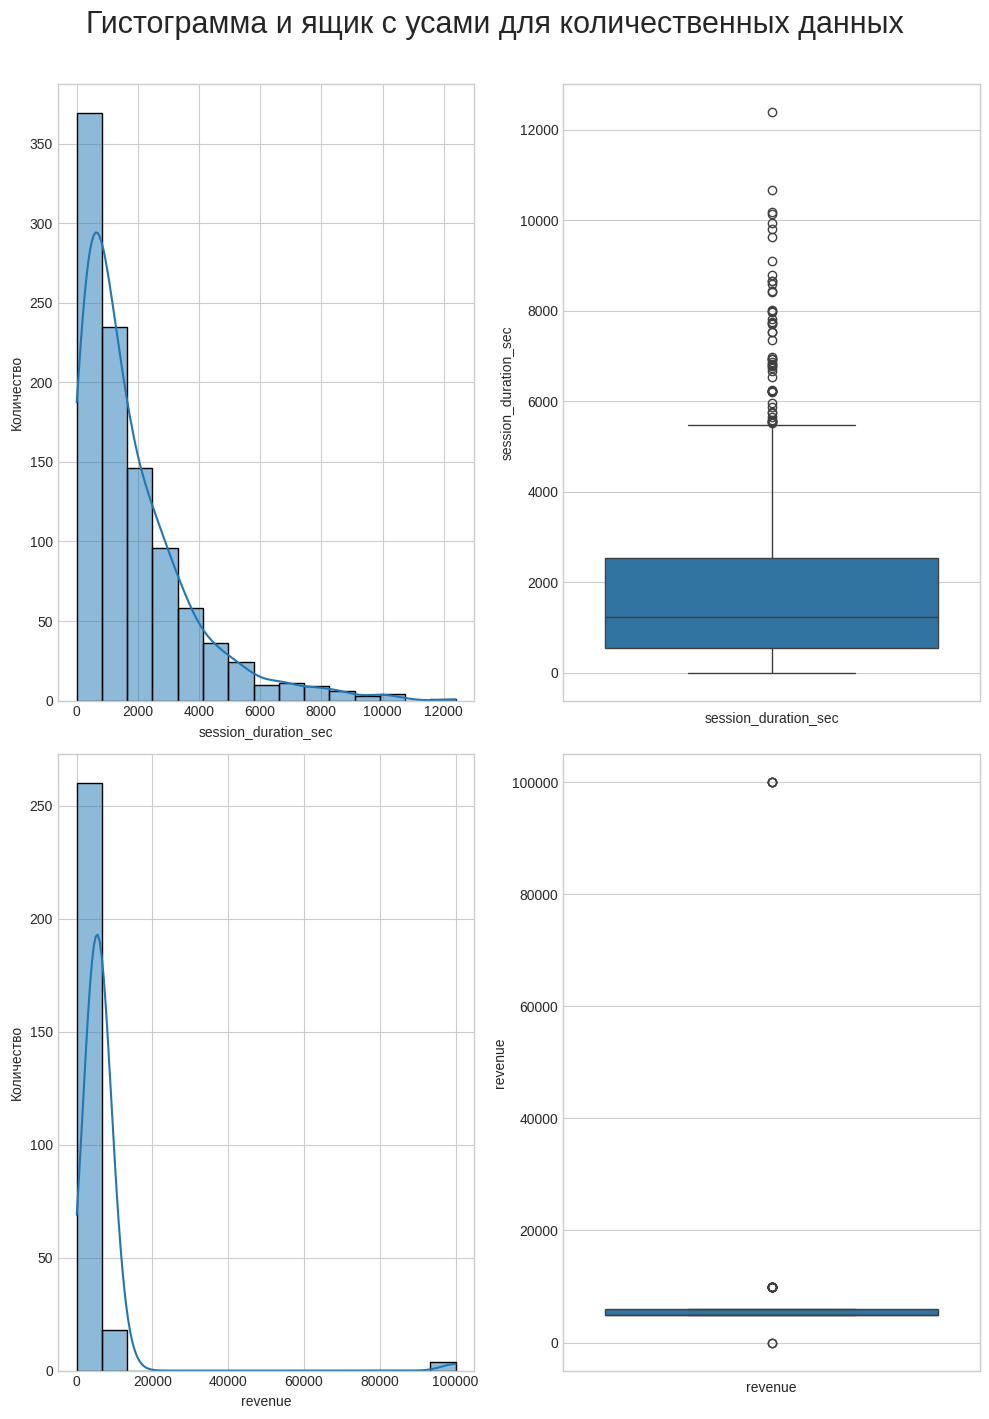

In [ ]:
draw_hist_box_plots(df_update[select_col])

In [ ]:
# возможные значения цены

df_update['revenue'].value_counts()

,count
revenue,
"4,999.000000",192
"5,999.000000",66
"9,999.000000",18
"100,000.000000",4
1.000000,2


In [ ]:
df_update.loc[(df_update['revenue'] == 1) | (df_update['revenue'] > 10000)]

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
55,649969085224,United States,PC,organic,2025-05-15 23:16:53,2025-05-15 23:28:04,671.000000,2025-05-15,5,3,23,2025-05-15 23:16:53,1.000000,Cash,0.000000
56,777891466332,United States,iPhone,социальные сети,2025-05-15 15:52:06,2025-05-15 16:18:32,"1,586.000000",2025-05-15,5,3,16,2025-05-15 15:52:06,1.000000,Mobile payments,0.000000
95,94160026069,France,Mac,реклама у блогеров,2025-05-21 08:17:29,2025-05-21 08:24:15,406.000000,2025-05-21,5,2,8,2025-05-21 08:17:29,"100,000.000000",Mobile payments,0.000000
96,422703292792,France,PC,organic,2025-05-21 14:19:29,2025-05-21 14:48:00,"1,711.000000",2025-05-21,5,2,14,2025-05-21 14:19:29,"100,000.000000",Mobile payments,1.000000
97,822055781011,United States,iPhone,реклама у блогеров,2025-05-21 05:50:33,2025-05-21 06:17:17,"1,604.000000",2025-05-21,5,2,6,2025-05-21 05:50:33,"100,000.000000",Debit card,0.000000
100,744763558101,UK,PC,organic,2025-05-22 04:11:46,2025-05-22 04:26:58,912.000000,2025-05-22,5,3,4,2025-05-22 04:11:46,"100,000.000000",E-wallet,0.000000


In [ ]:
def calculate_percentile(df: pd.Series):
  lst = df.loc[df.notna()]

  res = {
      'Q1': np.percentile(lst, 25),
      'Q2': np.percentile(lst, 50),
      'Q3': np.percentile(lst, 75),
  }
  res['IQR'] = res['Q3'] - res['Q1']
  res['Q1 - 1.5 * IQR'] = res['Q1'] - 1.5 * res['IQR']
  res['Q3 + 1.5 * IQR'] = res['Q3'] + 1.5 * res['IQR']

  return res

In [ ]:
revenue_percentiles = calculate_percentile(df_update['revenue'])
session_duration_percentiles = calculate_percentile(df_update['session_duration_sec'])

print('revenue')
for key, value in revenue_percentiles.items():
  print(f'{key}: {value}')

print('\n', '-' * 40)

print('session_duration_sec')
for key, value in session_duration_percentiles.items():
  print(f'{key}: {value}')

revenue
Q1: 4999.0
Q2: 4999.0
Q3: 5999.0
IQR: 1000.0
Q1 - 1.5 * IQR: 3499.0
Q3 + 1.5 * IQR: 7499.0

 ----------------------------------------
session_duration_sec
Q1: 538.9999997976702
Q2: 1230.5000000400469
Q3: 2526.249999931315
IQR: 1987.2500001336448
Q1 - 1.5 * IQR: -2441.875000402797
Q3 + 1.5 * IQR: 5507.125000131782


**Revenue:**
- Сумма покупки 1.0 (0,71%) и 100_000.0 (1,42%) составляют довольно маленький процент от всего количества покупателей (282). Поэтому удаляем их.

In [ ]:
# удаление выбросов

df_update = df_update.loc[(df_update['revenue'] != 1) & (df_update['revenue'] != 100000)]

# проверка
df_update['revenue'].value_counts()

,count
revenue,
"4,999.000000",192
"5,999.000000",66
"9,999.000000",18


**Session Duration Sec:**
- Под большими значениями могут быть оставленные открытыми вкладки, сессия которых закончилась автоматически из-за бездействия, или они просто были оставлены открытыми.
- Можно заменить всё, что больше верхней границы тройного межквартильного размаха (x > Q3 + 1,5 * IQR), на медианное значение среди сгруппированных по признакам столбцам

In [ ]:
def print_group_median(df, column_group, column_value='session_duration_sec'):
  print(column_group)
  print(df.groupby(column_group)[column_value].median())
  print('-' * 40)

In [ ]:
# рассмотрим возможные группировки и какие могут быть значения для медианных выбросов

possible_groups = [
    'region', 'device', 'channel',
    ['region', 'device'], ['region', 'channel'], ['device', 'channel'],
    ['region', 'device', 'channel']
]

for group in possible_groups:
  print_group_median(df_update, group)

region
region
France          1,304.500000
Germany         1,250.000000
UK              1,280.000000
United States   1,223.000000
Name: session_duration_sec, dtype: float64
----------------------------------------
device
device
Android   1,301.000000
Mac       1,296.000000
PC        1,173.000000
iPhone    1,177.000000
Name: session_duration_sec, dtype: float64
----------------------------------------
channel
channel
email-рассылки        1,269.500000
organic               1,201.000000
контекстная реклама   1,451.000000
реклама у блогеров    1,308.000000
социальные сети       1,220.000000
Name: session_duration_sec, dtype: float64
----------------------------------------
['region', 'device']
region         device 
France         Android   1,590.500000
               Mac       1,221.000000
               PC        1,113.500000
               iPhone    1,098.000000
Germany        Android     888.500000
               Mac       2,017.000000
               PC        1,206.000000
           

Медианные значения между различными группировками очень сильно варьируются, поэтому лучше возьмём значения для групп, разделённых по ['region', 'device', 'channel'].

In [ ]:
def replace_outlets(group_series):
    q1 = np.percentile(group_series, 25)
    q3 = np.percentile(group_series, 75)
    iqr = q3 - q1
    median = group_series.median()
    upper_bound = median + 1.5 * iqr
    return np.where(group_series > upper_bound, median, group_series)

In [ ]:
df_update['session_duration_sec'] = (
    df_update
    .groupby(['region', 'device', 'channel'])['session_duration_sec']
    .transform(replace_outlets)
)

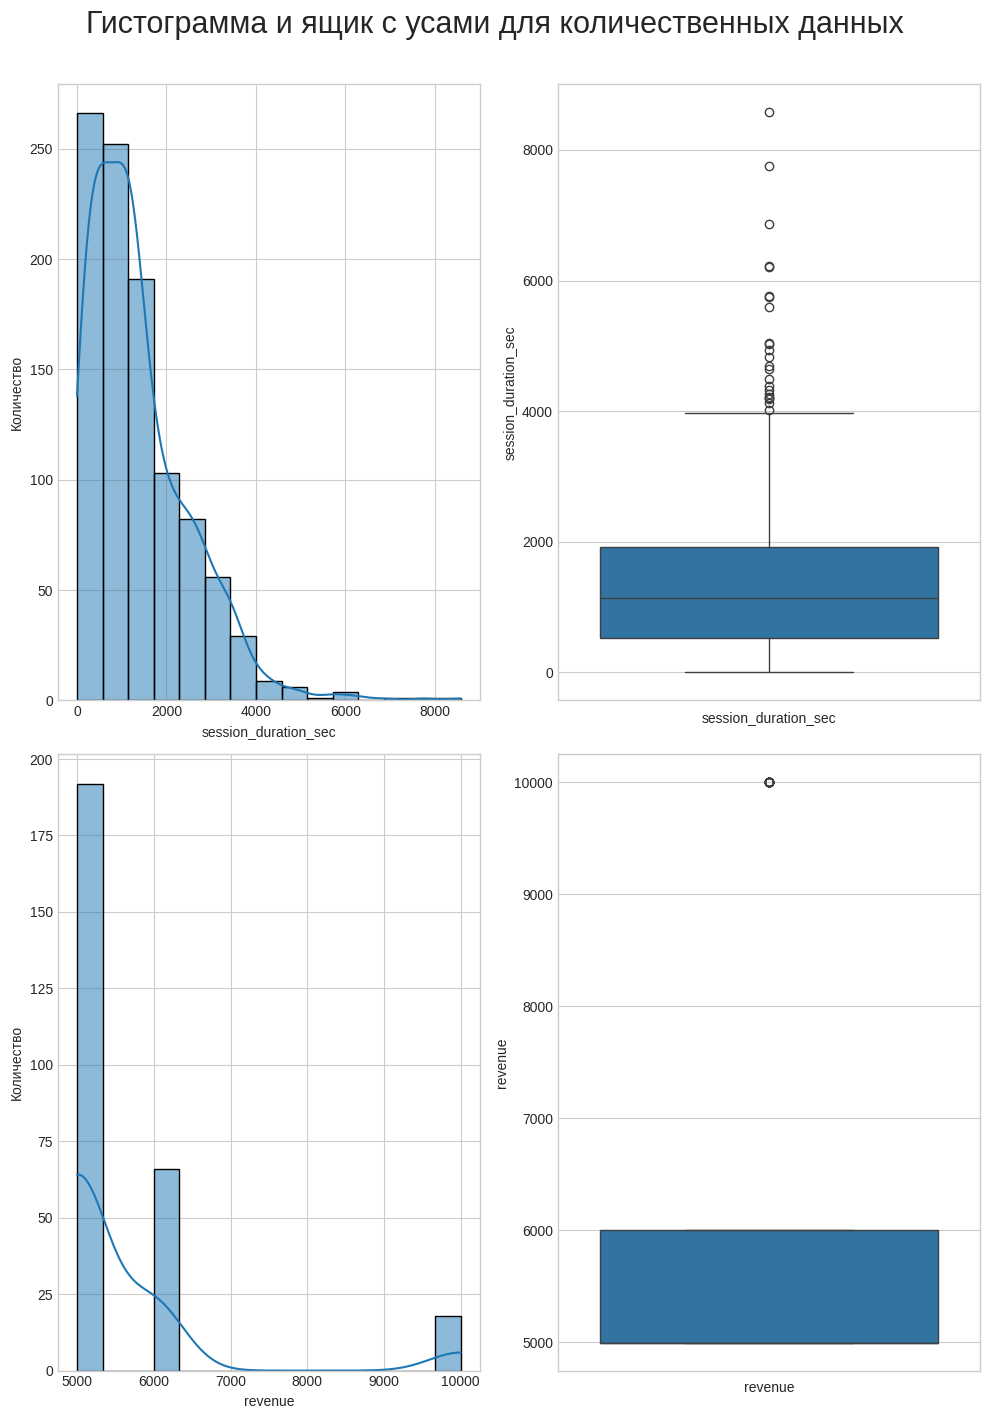

In [ ]:
# проверка после удаления выбросов
draw_hist_box_plots(df_update[select_col])

В конечном итоге, распределение данных не сильно поменялось и по своей структуре похоже на то, что было до этого.

### 2.7. Создание новых признаков

In [ ]:
# итоговая сумма покупки с учётом применения промокода на скидку 10%

df_update['total_payment'] = df_update['revenue']
mask = df_update['promo_code'].notna()
df_update.loc[mask, 'total_payment'] = df_update.loc[mask, 'revenue'] * (1 - 0.1 * df_update.loc[mask, 'promo_code'])

In [ ]:
def get_times_of_the_day(hour):
  if 6 <= hour <= 9:
    return 'утро'
  if 10 <= hour <= 16:
    return 'день'
  if 17 <= hour <= 21:
    return 'вечер'
  return 'ночь'

# времена суток
df_update['time_of_day'] = df_update['hour_of_day'].apply(get_times_of_the_day)

In [ ]:
# является ли пользователь покупателем
df_update['payer'] = 0
df_update.loc[df_update['promo_code'].notna(), 'payer'] = 1

In [ ]:
df_update.head()

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_payment,time_of_day,payer
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000,"9,999.000000",ночь,1
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN,утро,0
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.000000,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,NaN,ночь,0
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.000000,2025-05-01,5,3,18,NaT,NaN,NaN,NaN,NaN,вечер,0
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.000000,2025-05-02,5,4,14,NaT,NaN,NaN,NaN,NaN,день,0


### 2.8. Корреляция признаков

In [ ]:
df_numeric = df_update.select_dtypes(include=['number']).drop('user_id', axis=1)

df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1002 entries, 0 to 1011
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   session_duration_sec  1002 non-null   float64
 1   month                 1002 non-null   int64  
 2   day                   1002 non-null   int64  
 3   hour_of_day           1002 non-null   int64  
 4   revenue               276 non-null    float64
 5   promo_code            276 non-null    float64
 6   total_payment         276 non-null    float64
 7   payer                 1002 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 70.5 KB


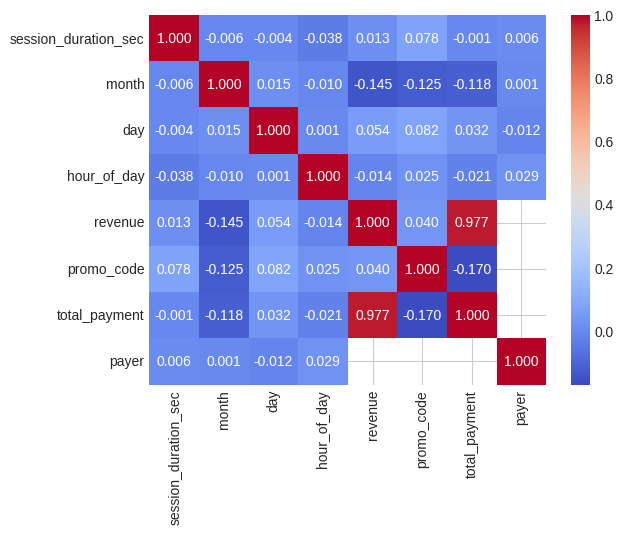

In [ ]:
corr_matrix = df_numeric.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f'
)
plt.show()

Как можно заметить, сильная корреляция между признаками присутствует только у `revenue` и `total_payment`. Это объяснимо тем, что второе было произведено из первого

### 2.9. Итоги предобработки

In [ ]:
csv_refined_path = os.getenv('DATA_REFINED_PATH')

In [ ]:
# Сохранение обработаного датасета

df_update.to_csv(csv_refined_path)

В процессе обработки были сделаные следующие преобразования:

1. Преобразование наименований столбцов к PEP8;
2. Исправлены опечатки в признаках с категориальным типом данных;
3. Обработаны пропуски в признаках region, device и channel через нахождение записей с одинаковым user_id и исследование, есть ли связь между похожими по первым 1-2 цифрам и количеством цифр всего user_id;
4. Поиск неявных дубликатов привёл к особенности датасета: если пользователь заходит повторно, то в 9 из 11 случаев он совершит похожее действие (просмотр или покупку);
5. Удалены объекты-выбросы, где сумма покупки равна 1.0 или 100_000.0 (их мало - в сумме 6 записей на 1012, и в дальнейшем они будут сильно влиять на чувствительные процессы, например, построение линейной регрессии), а также длина сессии равна 0 секунд;
6. Созданы новые признаки: итоговая сумма покупки, время суток, бинарная классификация, является ли пользователь покупателем;
7. Исследование на мультиколлинеарность показало, что только пара revenue-total_payment имеет сильную положительную связь. Объясняется это тем, что одно образовано от второго.

## 3. Исследовательский анализ

### 3.0.1. Чтение очищенного датасета

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_path_refined = '/content/drive/MyDrive/анализ данных/ecom_refined.csv'

In [ ]:
data = pd.read_csv(
    csv_path_refined,
    index_col=0,
    parse_dates=['session_start', 'session_end', 'session_date', 'order_dt']
)

In [ ]:
data.head(2)

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_payment,time_of_day,payer
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000,"9,999.000000",ночь,1
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN,утро,0


In [ ]:
data.shape

(1002, 18)

Создадим датасет, который отвечает за ключевые характеристики пользователя (user_id, region, device, channel, payer: купил хотя бы один раз за несколько сессий), для того, чтобы провести исследовательский анализ на количество пользователей без их дубликатов

In [ ]:
# агрегации для столбцов
agg_dict = {
    # первые встречаемые, потому что для каждого user_id соответствует
    # только одна комбинация из этих категориальных данных
    'region': 'first',
    'device': 'first',
    'channel': 'first',

    # пользователь является покупателем, если купил хотя бы один раз
    'payer': 'max'
}

data_user = data.groupby('user_id').agg(agg_dict).reset_index()

Также создадим датасет, отвечающий исключительно за покупки, то есть без пустых значений

In [ ]:
data_purchases = data.loc[
    data['order_dt'].notna(),
    ['user_id', 'region', 'device', 'channel', 'month', 'day', 'hour_of_day', 'time_of_day', 'payment_type']
]

In [ ]:
data.shape, data_user.shape, data_purchases.shape

((1002, 18), (991, 5), (276, 9))

### 3.0.2. Класс для графического анализа

In [ ]:
class plot_drawing:
  def __init__(self):
    pass

  def check_cols_rows(self, rows, cols, amount):
    if cols * rows < amount:
      rows = ceil(amount / 2)
      cols = 2
    return rows, cols

  def check_axes(self, rows, cols, axes):
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    return axes

  def pie(self, df, column, title, ax=None, figsize=(10, 10)):
    colors = sns.color_palette('pastel')  # всего 10 цветов
    if ax is None:
      fig, ax = plt.subplots(figsize=figsize)

    data = df.groupby(column).size()
    ax.pie(
        x=data.values,
        colors=colors,
        labels=data.index,
        autopct='%1.1f%%',
        textprops={'fontsize': 10}
    )
    ax.set_title(title, fontsize=14)
    return ax

  def some_pies(self, df, columns, sample_title, cols=1, rows=1, figsize=(10, 10)):
    rows, cols = self.check_cols_rows(rows, cols, len(columns))

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

    axes = self.check_axes(rows, cols, axes)

    for idx, col in enumerate(columns):
        row = idx // cols
        col_idx = idx % cols
        self.pie(df, col, f'{sample_title} {col}', ax=axes[row][col_idx])

    # скрытие пустых графиков
    for idx in range(len(columns), rows * cols):
        row = idx // cols
        col_idx = idx % cols
        axes[row][col_idx].axis('off')

    plt.tight_layout()
    plt.show()

  def bar_plot(self, df, value, category, title, ax=None, figsize=(10, 10)):
    data = df.groupby([value, category]).size().unstack()
    if ax is None:
      fig, ax = plt.subplots(figsize=figsize)

    data.plot(
      kind='bar',
      rot=45,
      color=['lightskyblue', 'salmon'],
      title=title,
      ax=ax
    )

    ax.grid(axis='y', alpha=0.5)
    return ax

  def some_bars(self, df, values_columns, category, sample_title, cols=1, rows=1, figsize=(10, 10)):
    rows, cols = self.check_cols_rows(rows, cols, len(values_columns))

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

    axes = self.check_axes(rows, cols, axes)

    for idx, col in enumerate(values_columns):
        row = idx // cols
        col_idx = idx % cols
        self.bar_plot(df, col, category, f'{sample_title} {col}', ax=axes[row][col_idx])

    # скрытие пустых графиков
    for idx in range(len(values_columns), rows * cols):
        row = idx // cols
        col_idx = idx % cols
        axes[row][col_idx].axis('off')

    plt.tight_layout()
    plt.show()

  def line_plot(self, df, value, category, indexes, title, ax=None, figsize=(9, 9)):
    colors = sns.color_palette('pastel')  # всего 10 цветов
    if ax is None:
      fig, ax = plt.subplots(figsize=figsize)

    data = df.groupby([value, category]).size().unstack()
    data = data.reindex(indexes)

    sns.lineplot(
      data=data,
      dashes=False,
      ax=ax
    )
    ax.set_title(title)
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    return ax

  def some_line_plots(self, df, categories, values_indexes, sample_title, rows=1, cols=1, figsize=(15, 15)):
    rows, cols = self.check_cols_rows(
        rows, cols, len(values_indexes) * len(categories)
    )

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

    axes = self.check_axes(rows, cols, axes)

    for row, params in enumerate(values_indexes):
        for col, category in enumerate(categories):
          self.line_plot(
            df,
            params['value'],
            category,
            params['indexes'],
            f'{sample_title} {params['value']}-{category}',
            ax=axes[row][col]
          )

    # скрытие пустых графиков
    for idx in range(len(values_indexes) * len(categories), rows * cols):
        row = idx // cols
        col_idx = idx % cols
        axes[row][col_idx].axis('off')

    plt.subplots_adjust(right=0.8)
    plt.tight_layout()
    plt.show()

  def heatmap(self, df, categories, title, ax, fig, figsize=(10, 10)):
    data = df.groupby(categories).size().unstack()

    im = ax.imshow(
      data,
      cmap='summer_r',
      aspect='auto'
    )

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, fontsize=8)

    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    # значения на heatmap
    for i in range(len(data.index)):
      for j in range(len(data.columns)):
        text = ax.text(j, i, data.iloc[i, j], ha="center", va="center", color='black')

    # шкала значений справа от графика
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes("right", size="7%", pad="2%")
    cb = fig.colorbar(im, cax=cax)
    ax.set_title(title)
    return ax

  def some_heatmaps(self, df, list_categories: list[list[str]], sample_title: str, rows=1, cols=1, figsize=(10, 10)):
    rows, cols = self.check_cols_rows(
        rows, cols, len(list_categories)
    )

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

    axes = self.check_axes(rows, cols, axes)

    for ind, categories in enumerate(list_categories):
      row = ind // cols
      col = ind % cols
      self.heatmap(
        df,
        categories,
        f'{sample_title} {categories[0]}-{categories[1]}',
        ax=axes[row][col],
        fig=fig
      )

    # скрытие пустых графиков
    for idx in range(len(list_categories), rows * cols):
        row = idx // cols
        col_idx = idx % cols
        axes[row][col_idx].axis('off')

    plt.subplots_adjust(right=0.8)
    plt.tight_layout()
    plt.show()


In [ ]:
draws = plot_drawing()

In [ ]:
category_columns = ['region', 'device', 'channel']

### 3.1. Доля продаж

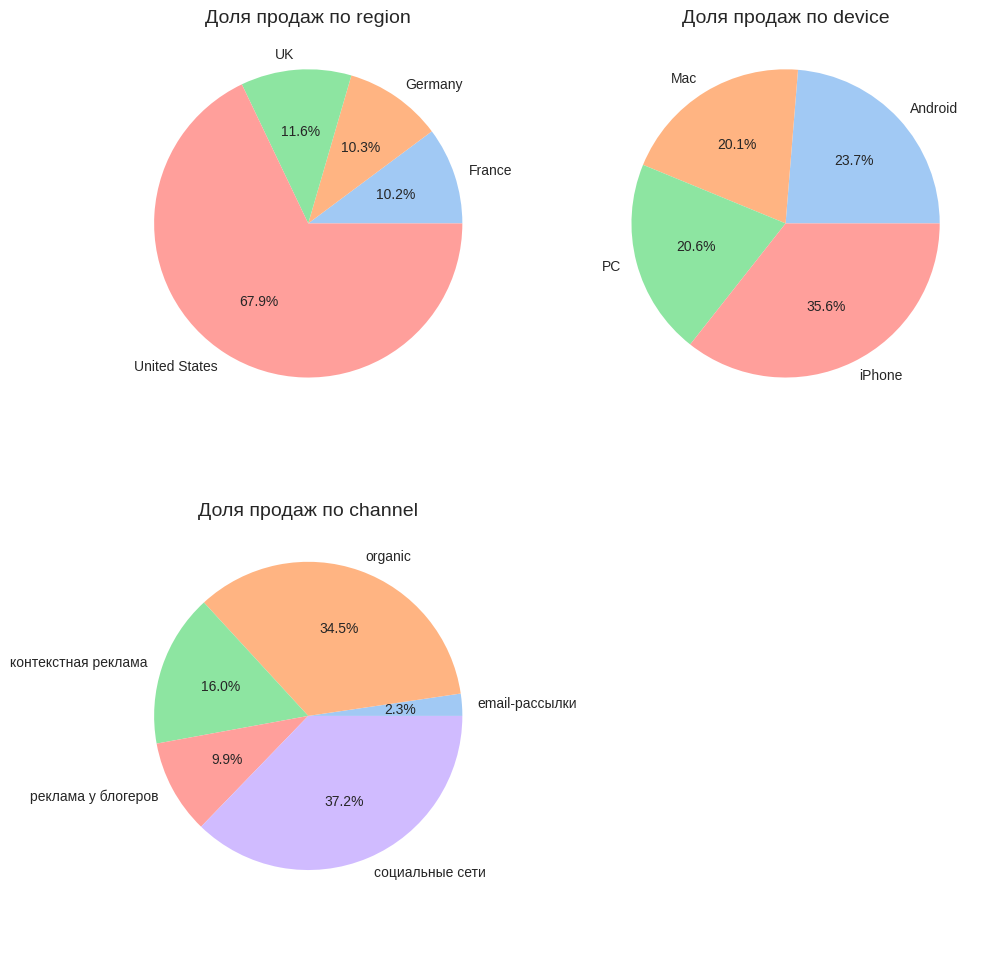

In [ ]:
draws.some_pies(data_user, category_columns, f'Доля продаж по', 2, 2)

Выводы:
>Доля США (67.9%): Составляет более двух третей от общего объема. Это абсолютное большинство, указывающее на то, основной потребитель сосредоточен именно в Соединенных Штатах. Европейские страны (суммарно ~32.1%): Великобритания, Германия и Франция вместе занимают примерно треть. При этом их показатели практически равны между собой, без явного лидера среди этой тройки.

>iPhone на первом месте, но остальные платформы не сильно отстают. Apple в целом популярнее — её устройствами пользуется больше половины людей (55.7%). Но полной монополии нет: аудитория разношёрстная, многие сидят на Android и других системах.

>Социальные сети напрямую приносят 37.2% продаж, однако их реальный вклад выше: органический трафик (34.5%) — во многом их отложенный эффект. В сумме два канала дают 71.7% выручки, что делает соцсети ключевым драйвером бизнеса. Платные каналы (контекст и блогеры) занимают 25.9% и играют вспомогательную роль. Email-рассылки (2.3%) малозначимы.


### 3.2. Количество пользователей с разбивкой на платящих и не платящих

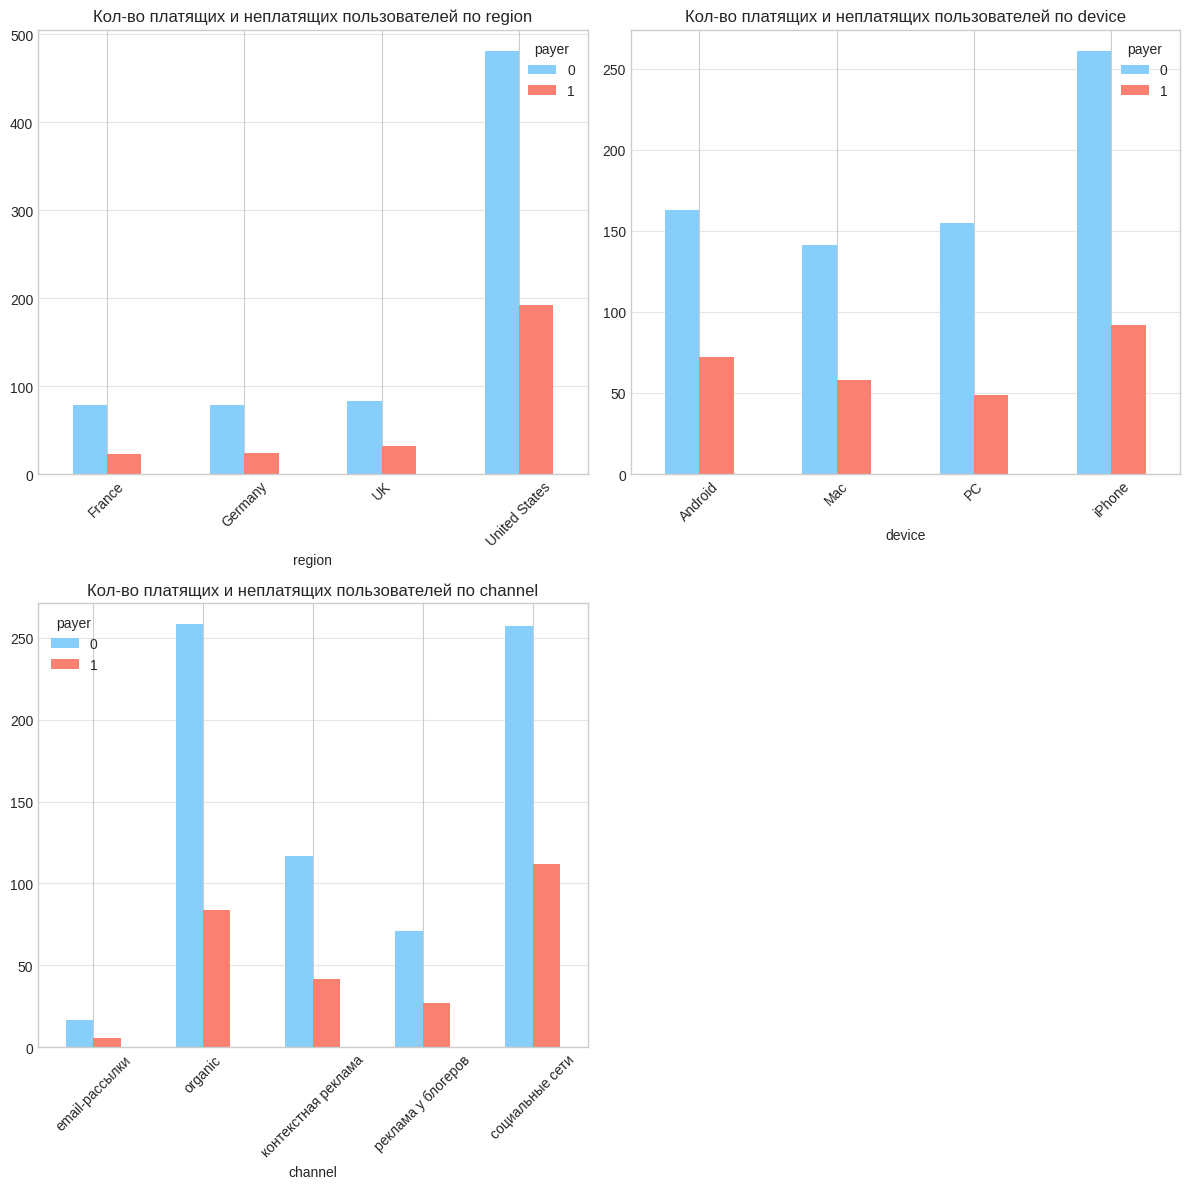

In [ ]:
draws.some_bars(data_user, category_columns, 'payer', 'Кол-во платящих и неплатящих пользователей по', 2, 2, figsize=(12, 12))

Вывод:
> Поскольку соотношение платящих и неплатящих пользователей во всех диаграммах примерно составляет отношение от 1:2 до 2:5, что прослеживается в каждом графике, сделанные ранее выводы о структуре продаж полностью применимы и к текущим данным.

### 3.3. Сезонность продаж

In [ ]:
data_params = [
  {
    'value': 'time_of_day',
    'indexes': ['утро', 'день', 'вечер', 'ночь']
  },
  {
    'value': 'month',
    'indexes': data_purchases.month.unique()
  },
  {
    'value': 'day',
    'indexes': [i for i in range(1, 8)]
  }
]

types = ['region', 'channel']

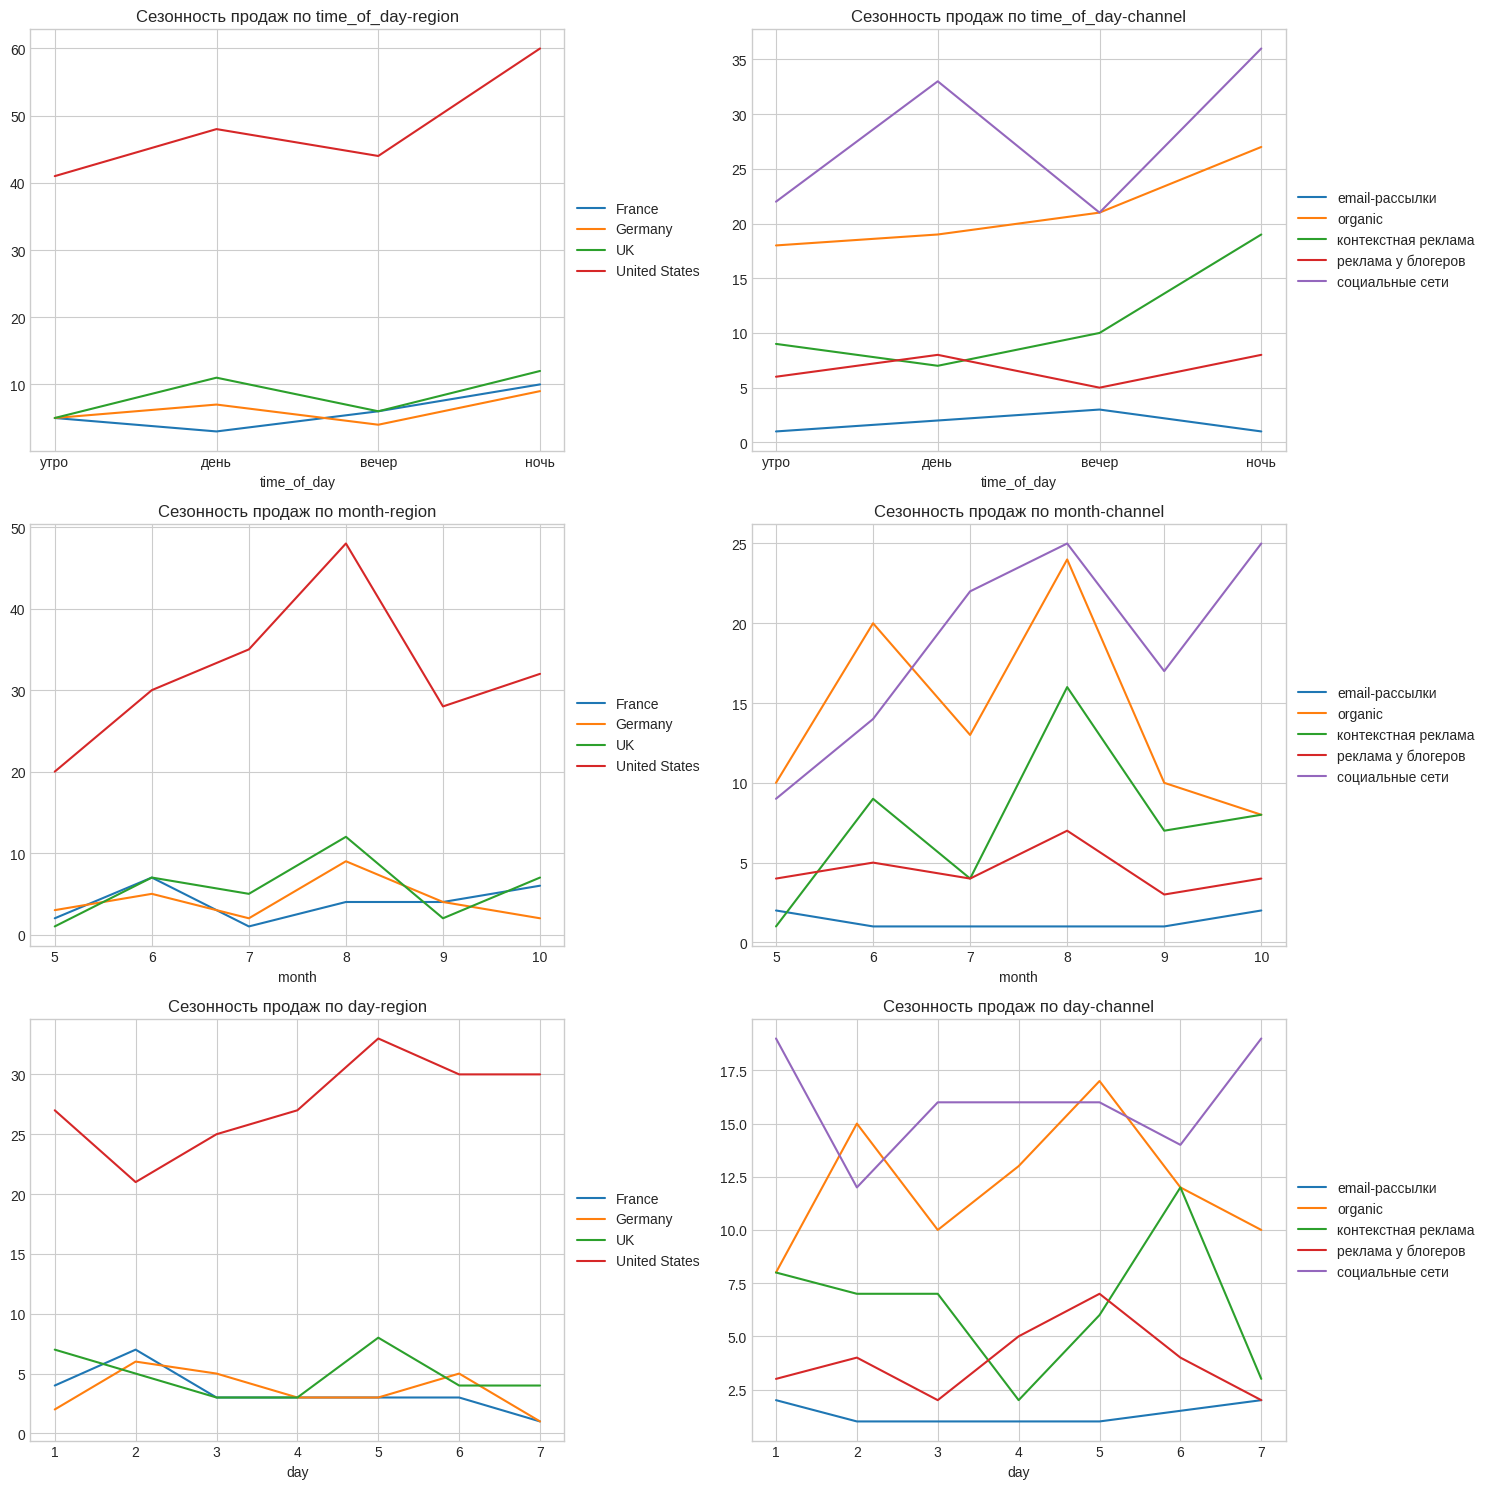

In [ ]:
draws.some_line_plots(data_purchases, types, data_params, 'Сезонность продаж по', 3, 2)

Выводы:
> Отчётливо наблюдается рост продаж в ночное время, что указывает на смещение покупательской активности к поздним часам.

> Самым прибыльным месяцем стал сентябрь, демонстрирующий резкий рост продаж по сравнению с предыдущими периодами и последующим спадом.

> Чётко выраженная сезонность по дням недели отсутствует — распределение продаж равномерно.

> Все графики подтверждают, что наибольший объём продаж приходится на США, причём основная доля продаж формируется за счёт социальных сетей и естественного (органического) трафика.

**Ниже представлены те же данные, но уже в виде тепловой карты**

In [ ]:
list_categories = [
    ['time_of_day', 'region'],
    ['time_of_day', 'channel'],
    ['month', 'region'],
    ['month', 'channel'],
    ['day', 'region'],
    ['day', 'channel']
]

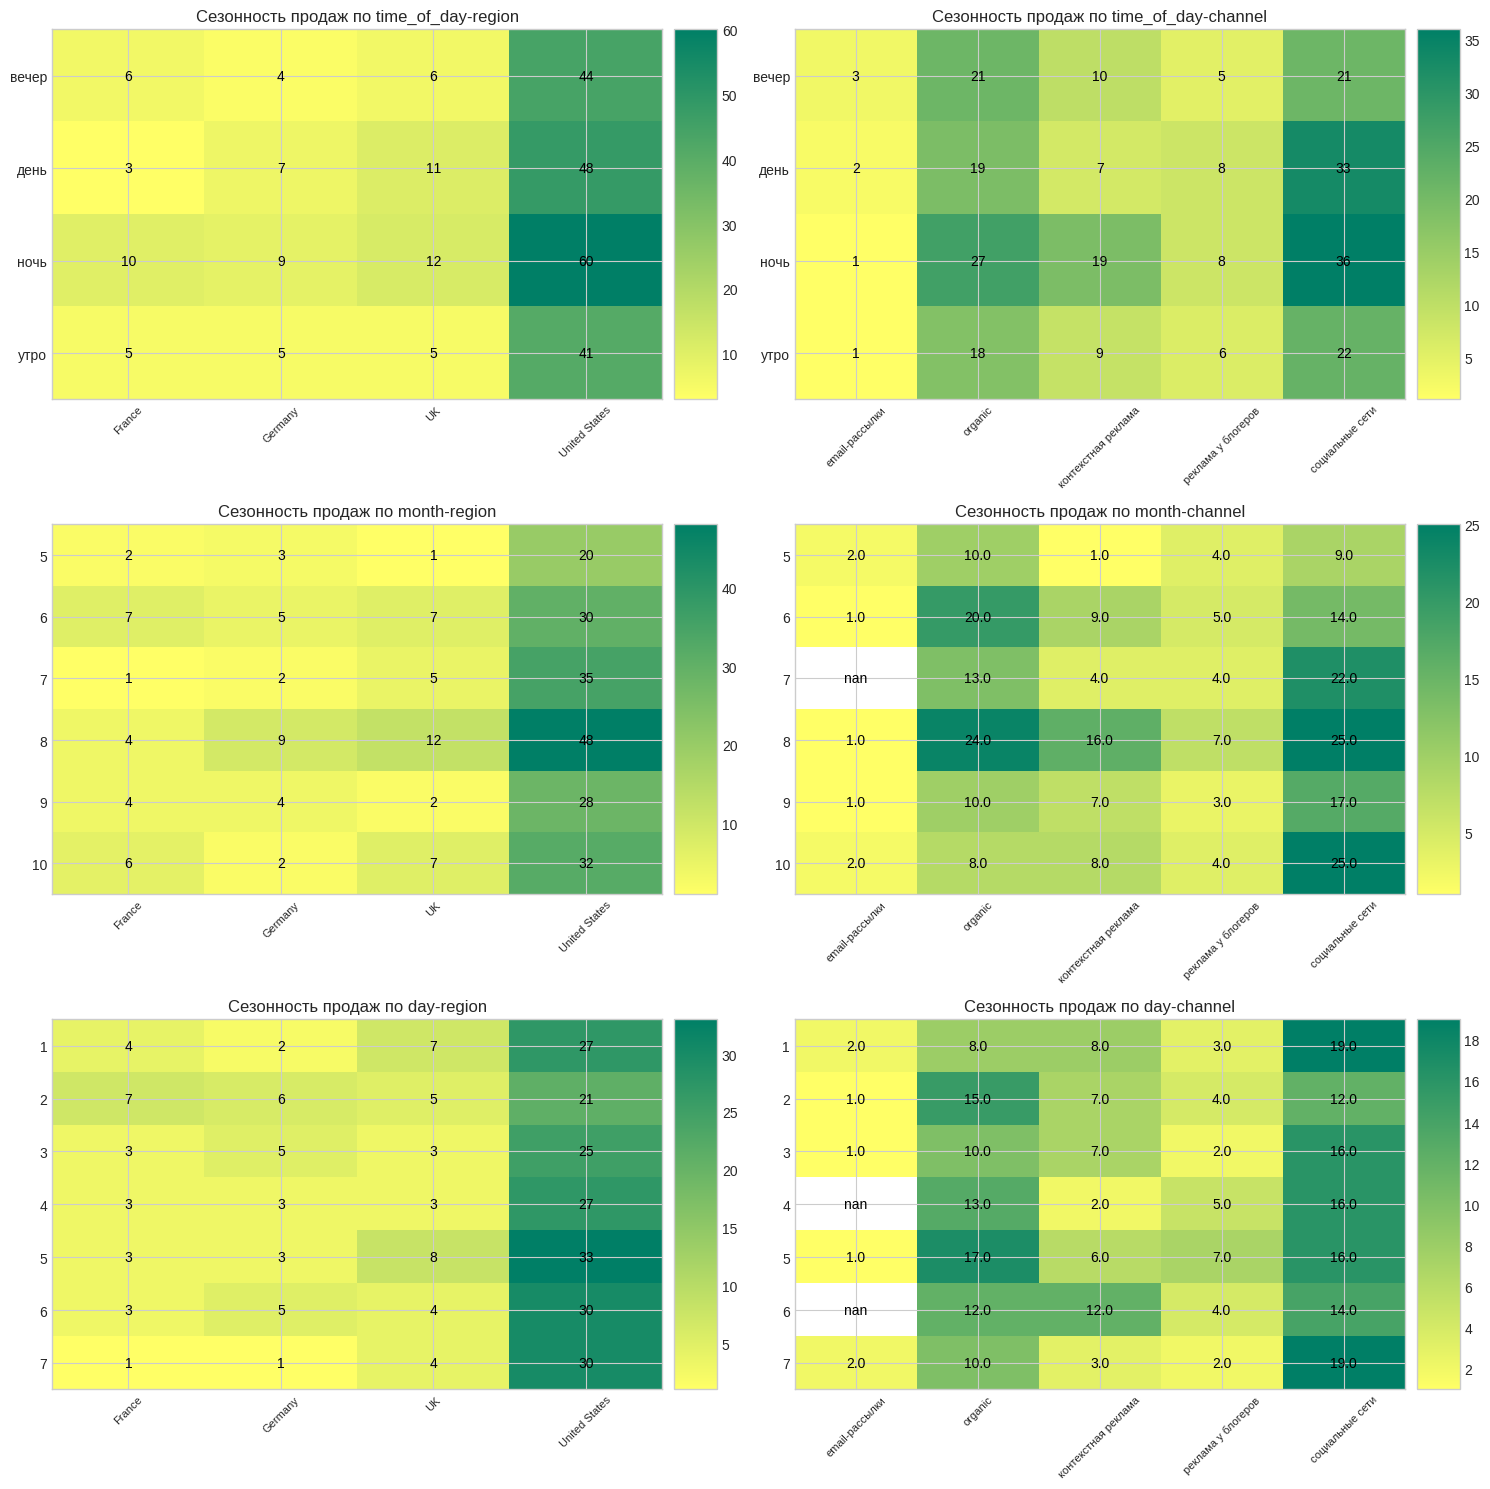

In [ ]:
draws.some_heatmaps(data_purchases, list_categories, 'Сезонность продаж по', figsize=(15, 15))

### 3.4. Тип оплаты

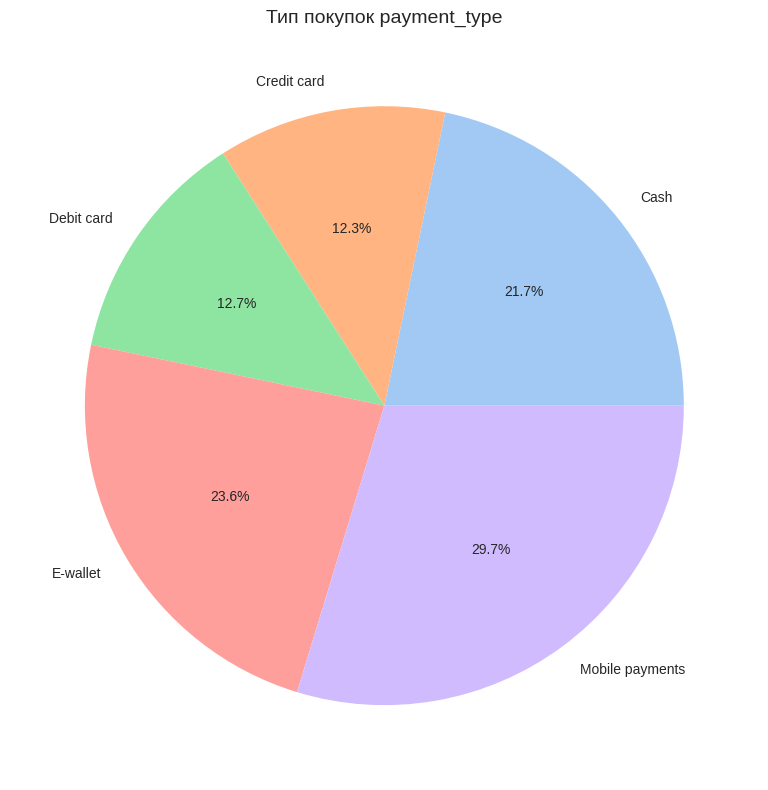

In [ ]:
draws.some_pies(data_purchases, ['payment_type'], 'Тип покупок', figsize=(8, 8))

Вывод:
>Мобильные платежи лидируют (29,7%), за ними следуют E-wallet (23,6%) и наличные (21,7%). Суммарно цифровые способы (мобильные + E-wallet) составляют 53,3% — вдвое больше наличных, тогда как банковские карты занимают наименьшую долю (дебетовые 12,7%, кредитные 12,3%).

### 3.5. Выводы исследовательского анализа




>Абсолютный лидер по продажам - США (67,9%), этот регион должен получить основной объём вложений. Европейские страны (Великобритания, Германия, Франция) в сумме дают около трети продаж, но их доли равномерны и без явного роста.

>Ключевой драйвер продаж - социальные сети и органический трафик, их совокупная доля составляет 71,7% выручки. Контекстная реклама и блогеры играют вспомогательную роль, email-канал практически бесполезен (2,3%).

>Временная сезонность: явный рост продаж в ночные часы - рекламные кампании стоит настраивать на позднее время. Самый прибыльный месяц - сентябрь с резким всплеском и последующим спадом. По дням недели значимой сезонности нет.

**Главная рекомендация:** инвестировать преимущественно в **США**, через **социальные сети** (с упором на ночное время и усилением в сентябре), продолжая поддерживать **органический трафик**. Остальные каналы и регионы — ограниченно.

## 4. Рассчёты и гипотезы

### 4.0 Импорт данных

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

csv_path_refined = '/content/drive/MyDrive/анализ данных/ecom_refined.csv'

df = pd.read_csv(
    csv_path_refined,
    index_col=0,
    parse_dates=['session_start', 'session_end', 'session_date', 'order_dt']
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_payment,time_of_day,payer
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000,"9,999.000000",ночь,1
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN,утро,0
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.000000,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,NaN,ночь,0
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.000000,2025-05-01,5,3,18,NaT,NaN,NaN,NaN,NaN,вечер,0
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.000000,2025-05-02,5,4,14,NaT,NaN,NaN,NaN,NaN,день,0


### 4.1. Проведение расчётов

#### Рассмотрим средние значения касательно покупателя и покупок

Обозначим следующую терминологию:

`Пользователь` - потенциальный клиент, сессия которого зафиксирована.

`Покупатель` - пользователь, который совершил хотя бы одну покупку, в течение некоторого периода.

In [ ]:
print(f'Соотношение покупателей к пользоватям: {df['payer'].sum() / df.shape[0]:.3f}')

print('-'*40)

print(f'Средний чек покупки: {df[df['payer'] == 1]['total_payment'].mean():.3f}')
print(f'Среднее количество покупок на одного пользователя: {df['payer'].sum() / df['user_id'].unique().size:.3f}')
print(f'Среднее количество покупок на одного покупателя: {df['payer'].sum() / df[df['payer'] == 1]['user_id'].unique().size:.3f}')

Соотношение покупателей к пользоватям: 0.275
----------------------------------------
Средний чек покупки: 5398.667
Среднее количество покупок на одного пользователя: 0.279
Среднее количество покупок на одного покупателя: 1.018


> Каждый четвёртый пользователь является покупателем, который в среднем совершает только одну покупку на сумму 5398.667.

#### Рассмотрим средние значения касательно сессий

In [ ]:
print('Средняя продолжительность сессии по рекламным каналам\n')

df.groupby('channel')['session_duration_sec'].mean().reset_index()

Средняя продолжительность сессии по рекламным каналам



,channel,session_duration_sec
0,email-рассылки,"1,726.083333"
1,organic,"1,344.862974"
2,контекстная реклама,"1,588.851852"
3,реклама у блогеров,"1,529.585859"
4,социальные сети,"1,236.250000"


Особо отличаются email-рассылка и социальные сети.

Объяснить это можно основной аудиторией этих каналов. В социальных сетях в большинстве своём сидит молодое поколение, а email-рассылками пользуются поколения постарше. Отсюда и разница в продолжительности сессии.

In [ ]:
print('Средняя продолжительность сессии по типу устройства\n')

df.groupby('device')['session_duration_sec'].mean().reset_index()

Средняя продолжительность сессии по типу устройства



,device,session_duration_sec
0,Android,"1,397.775210"
1,Mac,"1,394.278049"
2,PC,"1,452.560976"
3,iPhone,"1,292.717514"


Пользователи PC более склонны к длительному изучению сайта. Объяснить это можно тем, что у них больше экран, а с ним удобнее изучать каталог, смотреть отзывы.


#### Рассмотрим топ-3 критерия по среднему чеку

In [ ]:
print('Топ-3 рекламных канала по среднему чеку\n')

df.groupby('channel')['total_payment'].mean().sort_values(ascending=False).reset_index().head(3)

Топ-3 рекламных канала по среднему чеку



,channel,total_payment
0,социальные сети,"5,507.063393"
1,organic,"5,427.267059"
2,реклама у блогеров,"5,380.496296"


In [ ]:
print('Топ-3 региона по среднему чеку\n')

df.groupby('region')['total_payment'].mean().sort_values(ascending=False).reset_index().head(3)

Топ-3 региона по среднему чеку



,region,total_payment
0,UK,"5,478.432353"
1,United States,"5,415.093264"
2,Germany,"5,331.028000"


In [ ]:
print('Топ-3 месяца по среднему чеку с разбивкой по регионам\n')

df.groupby(['month', 'region'])['total_payment'].mean().sort_values(ascending=False).reset_index().head(3)

Топ-3 месяца по среднему чеку с разбивкой по регионам



,month,region,total_payment
0,7,Germany,"7,499.000000"
1,5,United States,"6,159.050000"
2,10,UK,"6,056.157143"


#### Отдельно уделим внимание рекламным каналам

In [ ]:
# MAU по каждому месяцу с разбивкой по рекламным каналам

mau = df.groupby(['month', 'channel'])['user_id'].nunique().reset_index()
mau.columns = ['month', 'channel', 'mau']
mau

,month,channel,mau
0,5,email-рассылки,7
1,5,organic,73
2,5,контекстная реклама,8
3,5,реклама у блогеров,12
4,5,социальные сети,40
5,6,email-рассылки,1
6,6,organic,59
7,6,контекстная реклама,28
8,6,реклама у блогеров,13
9,6,социальные сети,53


In [ ]:
print('Топ-3 рекламных каналов по среднему количеству уникальных пользователей в месяц\n')

mau.groupby('channel')['mau'].mean().sort_values(ascending=False).reset_index().head(3)

Топ-3 рекламных каналов по среднему количеству уникальных пользователей в месяц



,channel,mau
0,социальные сети,61.833333
1,organic,57.166667
2,контекстная реклама,27.000000


> Социальные сети с естественным потоком клиентов находятся почти вровень.

> Предположительно, что соцсети имеют большой обхват, а как следствие лучше работает сарафанное радио.

In [ ]:
print('Топ-3 рекламных каналов по количеству уникальных пользователей за последний месяц\n')

mau[mau['month'] == 10].sort_values('mau', ascending=False).reset_index(drop=True).head(3)

Топ-3 рекламных каналов по количеству уникальных пользователей за последний месяц



,month,channel,mau
0,10,социальные сети,85
1,10,organic,47
2,10,контекстная реклама,27


> Социальные сети привлекают уникальных пользователей практически в 2 раза больше, чем естественный поток

#### Таблица по рекламным каналам

В табице указано количество пользователей, количество уникальных пользователей, количество платящих пользователей и сумма продаж

In [ ]:
total = df.groupby('channel')['user_id'].count().reset_index(name='total_visits') # количество пользователей
unique = df.groupby('channel')['user_id'].nunique().reset_index(name='unique_users') # количество уникальных пользователей
paying = df[df['payer'] == 1].groupby('channel')['user_id'].count().reset_index(name='payers') # количество платящих пользователей
revenue = df.groupby('channel')['total_payment'].sum().reset_index(name='total_payment') # сумма продаж

result = total.merge(unique, on='channel')
result = result.merge(paying, on='channel')
result = result.merge(revenue, on='channel')

result

,channel,total_visits,unique_users,payers,total_payment
0,email-рассылки,24,23,7,"36,493.300000"
1,organic,343,342,85,"461,317.700000"
2,контекстная реклама,162,159,45,"230,156.600000"
3,реклама у блогеров,99,98,27,"145,273.400000"
4,социальные сети,374,369,112,"616,791.100000"


> По таблице видим, что больше всего платящих пользователей и большую сумму продаж "принёс" рекламный канал "социальные сети".


### 4.2. Проверка гипотез

#### Влияет ли тип устройства на количество покупок в день по каждому региону?


Нулевая гипотеза (H0): Тип устройства НЕ ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день одинаково для всех типов устройств в каждом регионе.

Альтернативная гипотеза (H1): Тип устройства ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день различается в зависимости от типа устройства хотя бы в одном регионе.

Количество покупок в день - количественная метрика

Тип устройства - номинальная метрика

Для начала сгруппируем данные по дате покупки, региону и типу устройства.

Если в какой-то день покупок с устройства не было, то ставим 0.

In [ ]:
df_payers = df[df['payer'] == 1]

df_payers.loc[:, 'order_dt'] = df_payers['order_dt'].dt.date

daily_purchases = df_payers.groupby(['order_dt', 'region', 'device']).size().reset_index(name='purchases_per_day')

regions = daily_purchases.region.unique()
devices = daily_purchases.device.unique()
dates = daily_purchases.order_dt.unique()

full_index = pd.MultiIndex.from_product(
    [regions, devices, dates],
    names=['region', 'device', 'order_dt']
)

daily_purchases_full = (
    daily_purchases
    .set_index(['region', 'device', 'order_dt'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

Визуализация

<Axes: xlabel='region'>

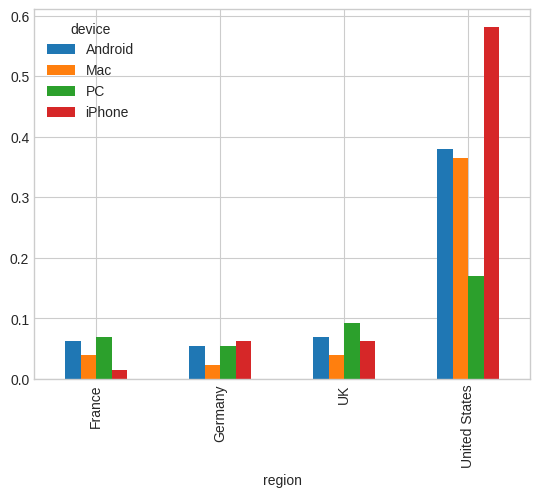

In [ ]:
pivot_mean = daily_purchases_full.pivot_table(
    values='purchases_per_day',
    index='region',
    columns='device',
    aggfunc='mean'
)
pivot_mean.plot(kind='bar')

В каждом регионе по 4 типа устройства.

Визульно заметно, что тип устройства ВЛИЯЕТ на количество покупок как минимум в United States.

Однако надо проверить и математически.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for device in daily_purchases_full.device.unique():
    data = daily_purchases_full[daily_purchases_full.device == device].purchases_per_day
    stat, p = stats.shapiro(data)
    print(f"{device}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

iPhone: p-value = 0.0000 → Ненормальное
Android: p-value = 0.0000 → Ненормальное
Mac: p-value = 0.0000 → Ненормальное
PC: p-value = 0.0000 → Ненормальное


Сравнение происходит по 4 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

for region in daily_purchases_full.region.unique():
    region_data = daily_purchases_full[daily_purchases_full.region == region]

    groups = []
    for device in region_data.device.unique():
        device_purchases = region_data[region_data.device == device].purchases_per_day.values
        groups.append(device_purchases)

    h_stat, p_value = stats.kruskal(*groups)

    print(f"{region}: p-value = {p_value:.4f} → ", end="")
    if p_value < alpha:
        print("ВЛИЯЕТ (отвергаем H0)")
    else:
        print("НЕ влияет (нет оснований отвергнуть H0)")

United States: p-value = 0.0000 → ВЛИЯЕТ (отвергаем H0)
Germany: p-value = 0.4798 → НЕ влияет (нет оснований отвергнуть H0)
France: p-value = 0.1555 → НЕ влияет (нет оснований отвергнуть H0)
UK: p-value = 0.3309 → НЕ влияет (нет оснований отвергнуть H0)


Так как в United States отвергается нулевая гипотеза, то отвергается и общая нулевая гипотеза. Принимается альтернативная.

Таким образом, тип устройства ВЛИЯЕТ на количество покупок в день.

#### Влияет ли тип рекламного канала на количество покупок в день по каждому региону?


Нулевая гипотеза (H0): Тип рекламного канала НЕ ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день одинаково для всех рекламных каналов в каждом регионе.

Альтернативная гипотеза (H1): Тип рекламного канала ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день различается в зависимости от типа рекламного канала хотя бы в одном регионе.

Количество покупок в день - количественная метрика

Тип рекламного канала - номинальная метрика

Для начала сгруппируем данные по дате покупки, региону и типу рекламного канала.

Если в какой-то день покупок от рекламного канала не было, то ставим 0.

In [ ]:
df_payers = df[df['payer'] == 1]

df_payers.loc[:, 'order_dt'] = df_payers['order_dt'].dt.date

daily_purchases = df_payers.groupby(['order_dt', 'region', 'channel']).size().reset_index(name='purchases_per_day')

regions = daily_purchases.region.unique()
channels = daily_purchases.channel.unique()
dates = daily_purchases.order_dt.unique()

full_index = pd.MultiIndex.from_product(
    [regions, channels, dates],
    names=['region', 'channel', 'order_dt']
)

daily_purchases_full = (
    daily_purchases
    .set_index(['region', 'channel', 'order_dt'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

Визуализация

<Axes: xlabel='region'>

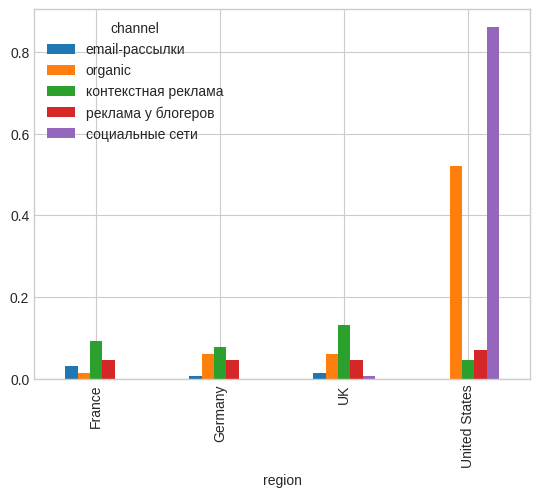

In [ ]:
pivot_mean = daily_purchases_full.pivot_table(
    values='purchases_per_day',
    index='region',
    columns='channel',
    aggfunc='mean'
)
pivot_mean.plot(kind='bar')

В каждом регионе по 5 типов рекламных каналов.

Визульно заметно, что тип рекламного канала ВЛИЯЕТ на количество покупок как минимум в United States и UK.

Однако надо проверить и математически.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for channel in daily_purchases_full.channel.unique():
    data = daily_purchases_full[daily_purchases_full.channel == channel].purchases_per_day
    stat, p = stats.shapiro(data)
    print(f"{channel}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

социальные сети: p-value = 0.0000 → Ненормальное
organic: p-value = 0.0000 → Ненормальное
реклама у блогеров: p-value = 0.0000 → Ненормальное
email-рассылки: p-value = 0.0000 → Ненормальное
контекстная реклама: p-value = 0.0000 → Ненормальное


Сравнение происходит по 5 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

for region in daily_purchases_full.region.unique():
    region_data = daily_purchases_full[daily_purchases_full.region == region]

    groups = []
    for channel in region_data.channel.unique():
        channel_purchases = region_data[region_data.channel == channel].purchases_per_day.values
        groups.append(channel_purchases)

    h_stat, p_value = stats.kruskal(*groups)

    print(f"{region}: p-value = {p_value:.4f} → ", end="")
    if p_value < alpha:
        print("ВЛИЯЕТ (отвергаем H0)")
    else:
        print("НЕ влияет (нет оснований отвергнуть H0)")

United States: p-value = 0.0000 → ВЛИЯЕТ (отвергаем H0)
Germany: p-value = 0.0080 → ВЛИЯЕТ (отвергаем H0)
France: p-value = 0.0073 → ВЛИЯЕТ (отвергаем H0)
UK: p-value = 0.0001 → ВЛИЯЕТ (отвергаем H0)


Так как во всех регионах отвергается нулевая гипотеза, то отвергается и общая нулевая гипотеза. Принимается альтернативная.

Таким образом, тип рекламного канала ВЛИЯЕТ на количество покупок в день.

#### Отличается ли средний чек в зависимости от региона?


Нулевая гипотеза (H0): Между регионами НЕТ РАЗЛИЧИЙ в среднем чеке. Все средние значения принадлежат одной генеральной совокупности.

Альтернативная гипотеза (H1): Средний чек между регионами ОТЛИЧАЕТСЯ. Хотя бы в одном регионе среднее статистически значимо отличается от других.

Сумма покупки - количественная метрика

Регион - номинальная метрика

Визуализация

In [ ]:
df_payers = df[df['payer'] == 1]

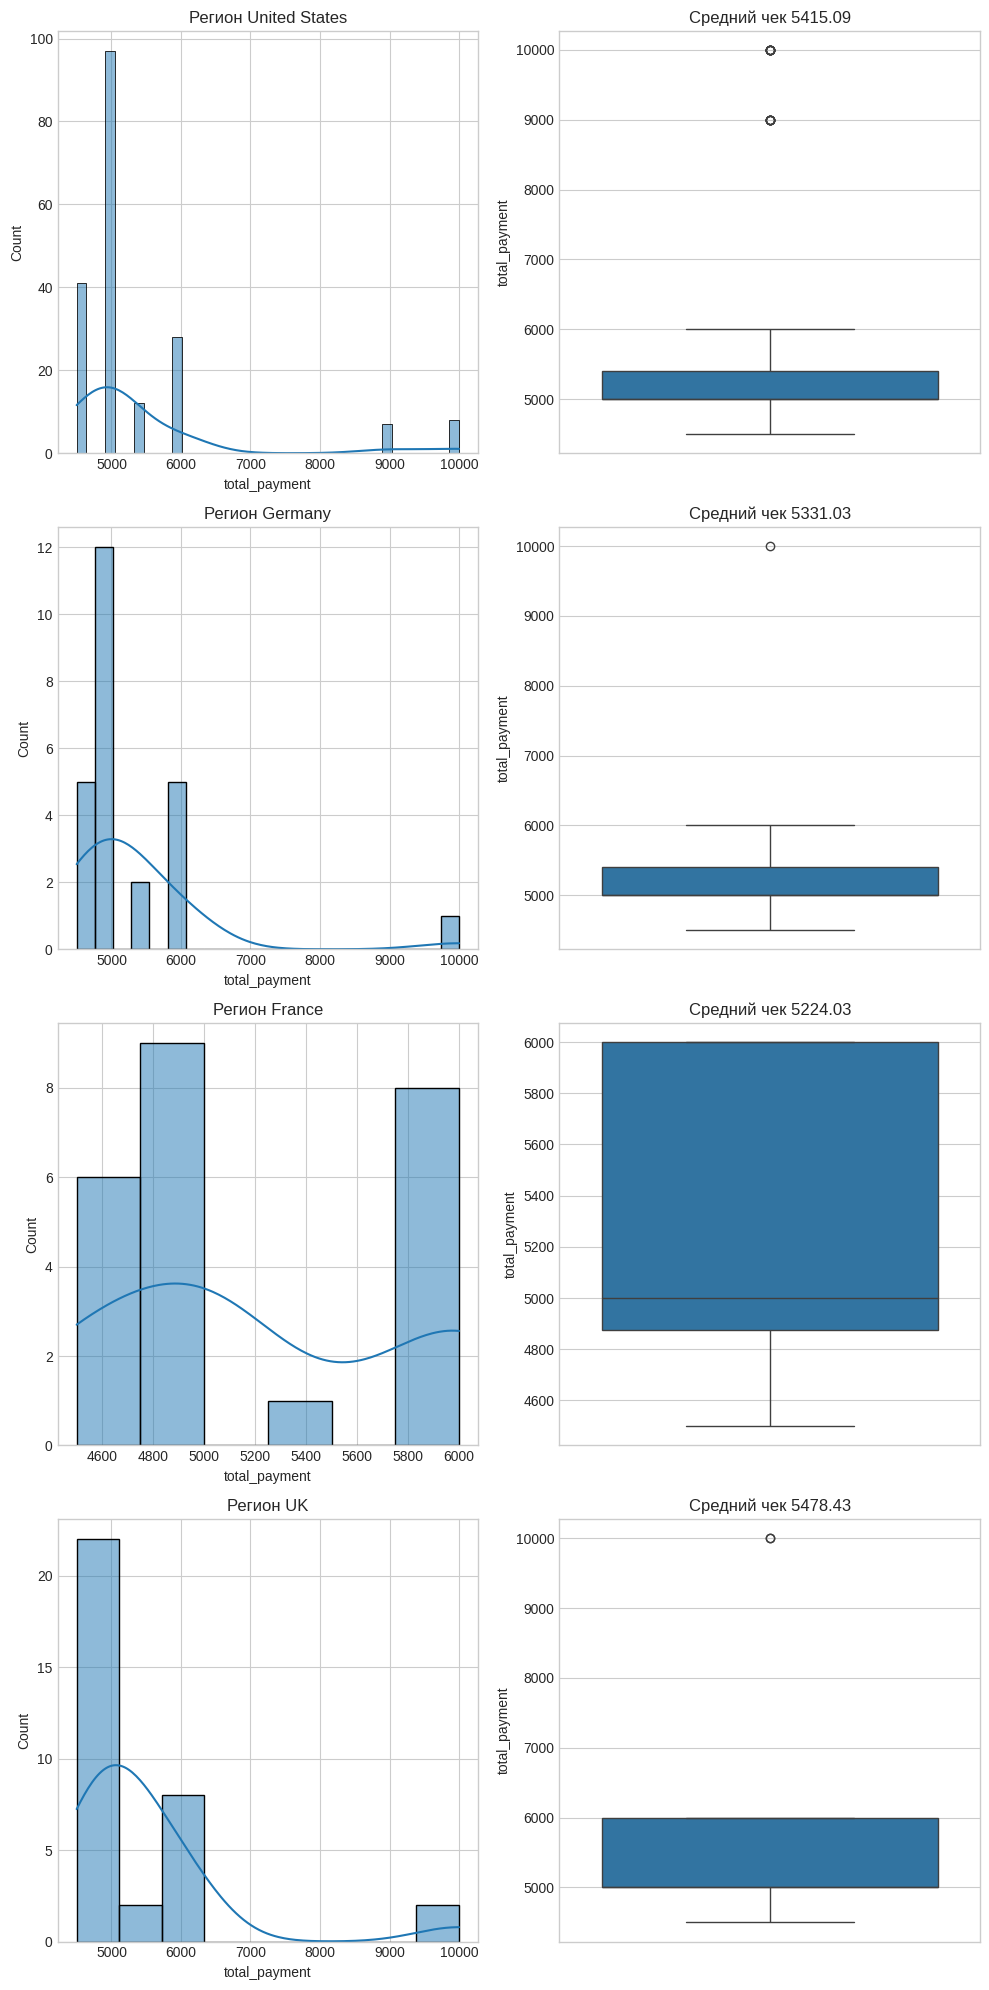

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(10,20))
for i, reg in enumerate(df_payers.region.unique()):
  data = df_payers[df_payers.region == reg]
  sns.histplot(data.total_payment, kde=True, ax=ax[i][0])
  sns.boxplot(data.total_payment, ax=ax[i][1])
  ax[i][0].set_title(f"Регион {reg}")
  ax[i][1].set_title(f"Средний чек {data.total_payment.mean():.2f}")
plt.tight_layout()
plt.show()

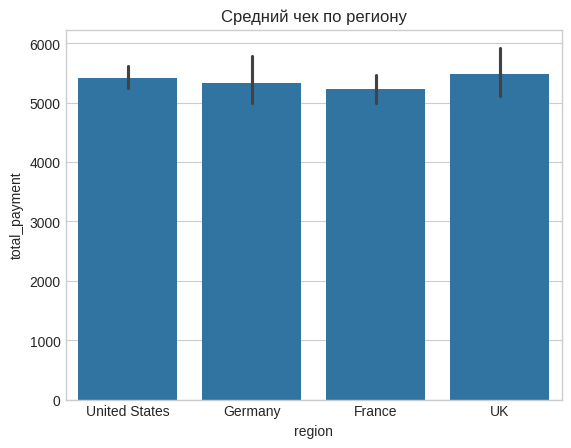

In [ ]:
sns.barplot(data=df_payers, x='region', y='total_payment', estimator="mean")
plt.title('Средний чек по региону')
plt.show()

По графикам заметно что средний чек НЕ РАЗЛИЧАЕТСЯ. Покажем это математически

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for reg in df_payers.region.unique():
    data = df_payers[df_payers.region == reg].total_payment
    stat, p = stats.shapiro(data)
    print(f"{reg}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

United States: p-value = 0.0000 → Ненормальное
Germany: p-value = 0.0000 → Ненормальное
France: p-value = 0.0003 → Ненормальное
UK: p-value = 0.0000 → Ненормальное


Сравнение происходит по 4 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for region in df_payers.region.unique():
    data = df_payers[df_payers.region == region]
    groups.append(data.total_payment.values)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.8090 → НЕ влияет (нет оснований отвергнуть H0)


Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, между регионами НЕТ РАЗЛИЧИЙ в среднем чеке.

#### Отличается ли средний чек в зависимости от рекламного канала?


Нулевая гипотеза (H0): Между рекламными каналами НЕТ РАЗЛИЧИЙ в среднем чеке. Все средние значения принадлежат одной генеральной совокупности.

Альтернативная гипотеза (H1): Средний чек между рекламными каналами ОТЛИЧАЕТСЯ. Хотя бы в одном рекламном канале среднее статистически значимо отличается от других.

Сумма покупки - количественная метрика

Рекламный канал - номинальная метрика

Визуализация

In [ ]:
df_payers = df[df['payer'] == 1]

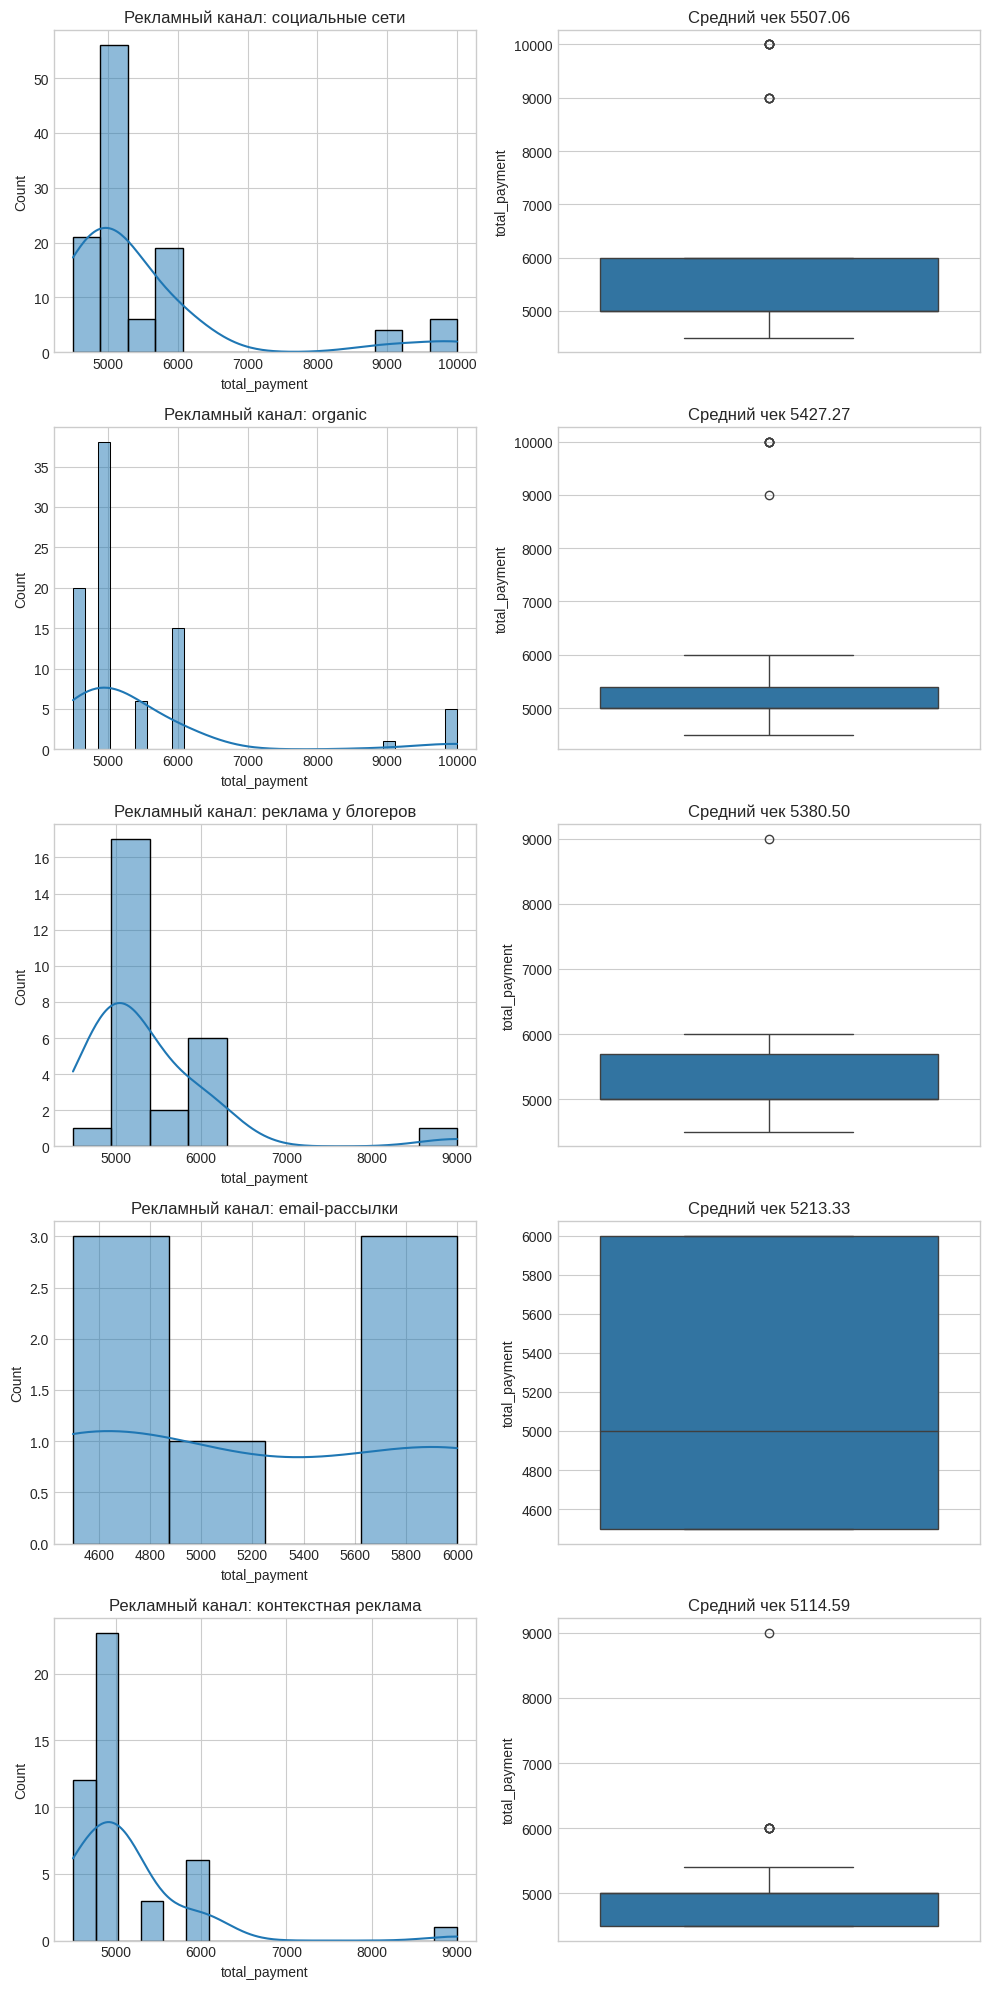

In [ ]:
fig, ax = plt.subplots(5, 2, figsize=(10,20))
for i, channel in enumerate(df_payers.channel.unique()):
  data = df_payers[df_payers.channel == channel]
  sns.histplot(data.total_payment, kde=True, ax=ax[i][0])
  sns.boxplot(data.total_payment, ax=ax[i][1])
  ax[i][0].set_title(f"Рекламный канал: {channel}")
  ax[i][1].set_title(f"Средний чек {data.total_payment.mean():.2f}")
plt.tight_layout()
plt.show()

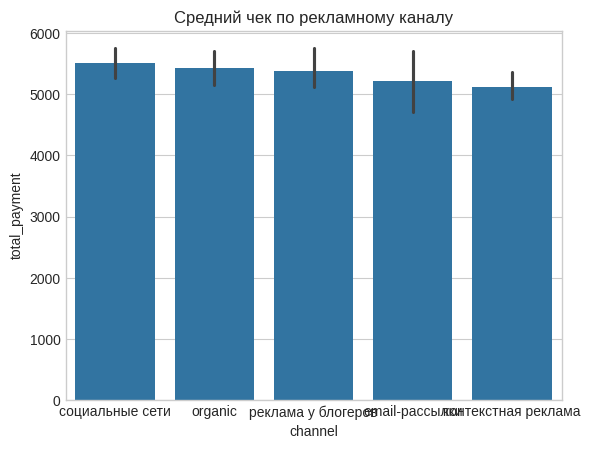

In [ ]:
sns.barplot(data=df_payers, x='channel', y='total_payment', estimator="mean")
plt.title('Средний чек по рекламному каналу')
plt.show()

По графикам заметно что средний чек НЕ РАЗЛИЧАЕТСЯ. Покажем это математически

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for channel in df_payers.channel.unique():
    data = df_payers[df_payers.channel == channel].total_payment
    stat, p = stats.shapiro(data)
    print(f"{channel}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

социальные сети: p-value = 0.0000 → Ненормальное
organic: p-value = 0.0000 → Ненормальное
реклама у блогеров: p-value = 0.0000 → Ненормальное
email-рассылки: p-value = 0.0119 → Ненормальное
контекстная реклама: p-value = 0.0000 → Ненормальное


Сравнение происходит по 5 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for channel in df_payers.channel.unique():
    data = df_payers[df_payers.channel == channel]
    groups.append(data.total_payment.values)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.3854 → НЕ влияет (нет оснований отвергнуть H0)


Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, между рекламными канали НЕТ РАЗЛИЧИЙ в среднем чеке.

#### Отличается ли средний чек в зависимости от времени суток?


Нулевая гипотеза (H0): Между временем суток нет различий в среднем чеке. Все средние значения принадлежат одной генеральной совокупности.

Альтернативная гипотеза (H1): Средний чек различается в зависимости от времени суток. Хотя бы в одном из периодов среднее статистически значимо отличается от других.

Сумма покупки - количественная метрика

Время суток - номинальная метрика

Визуализация

In [ ]:
df_payers = df[df['payer'] == 1]

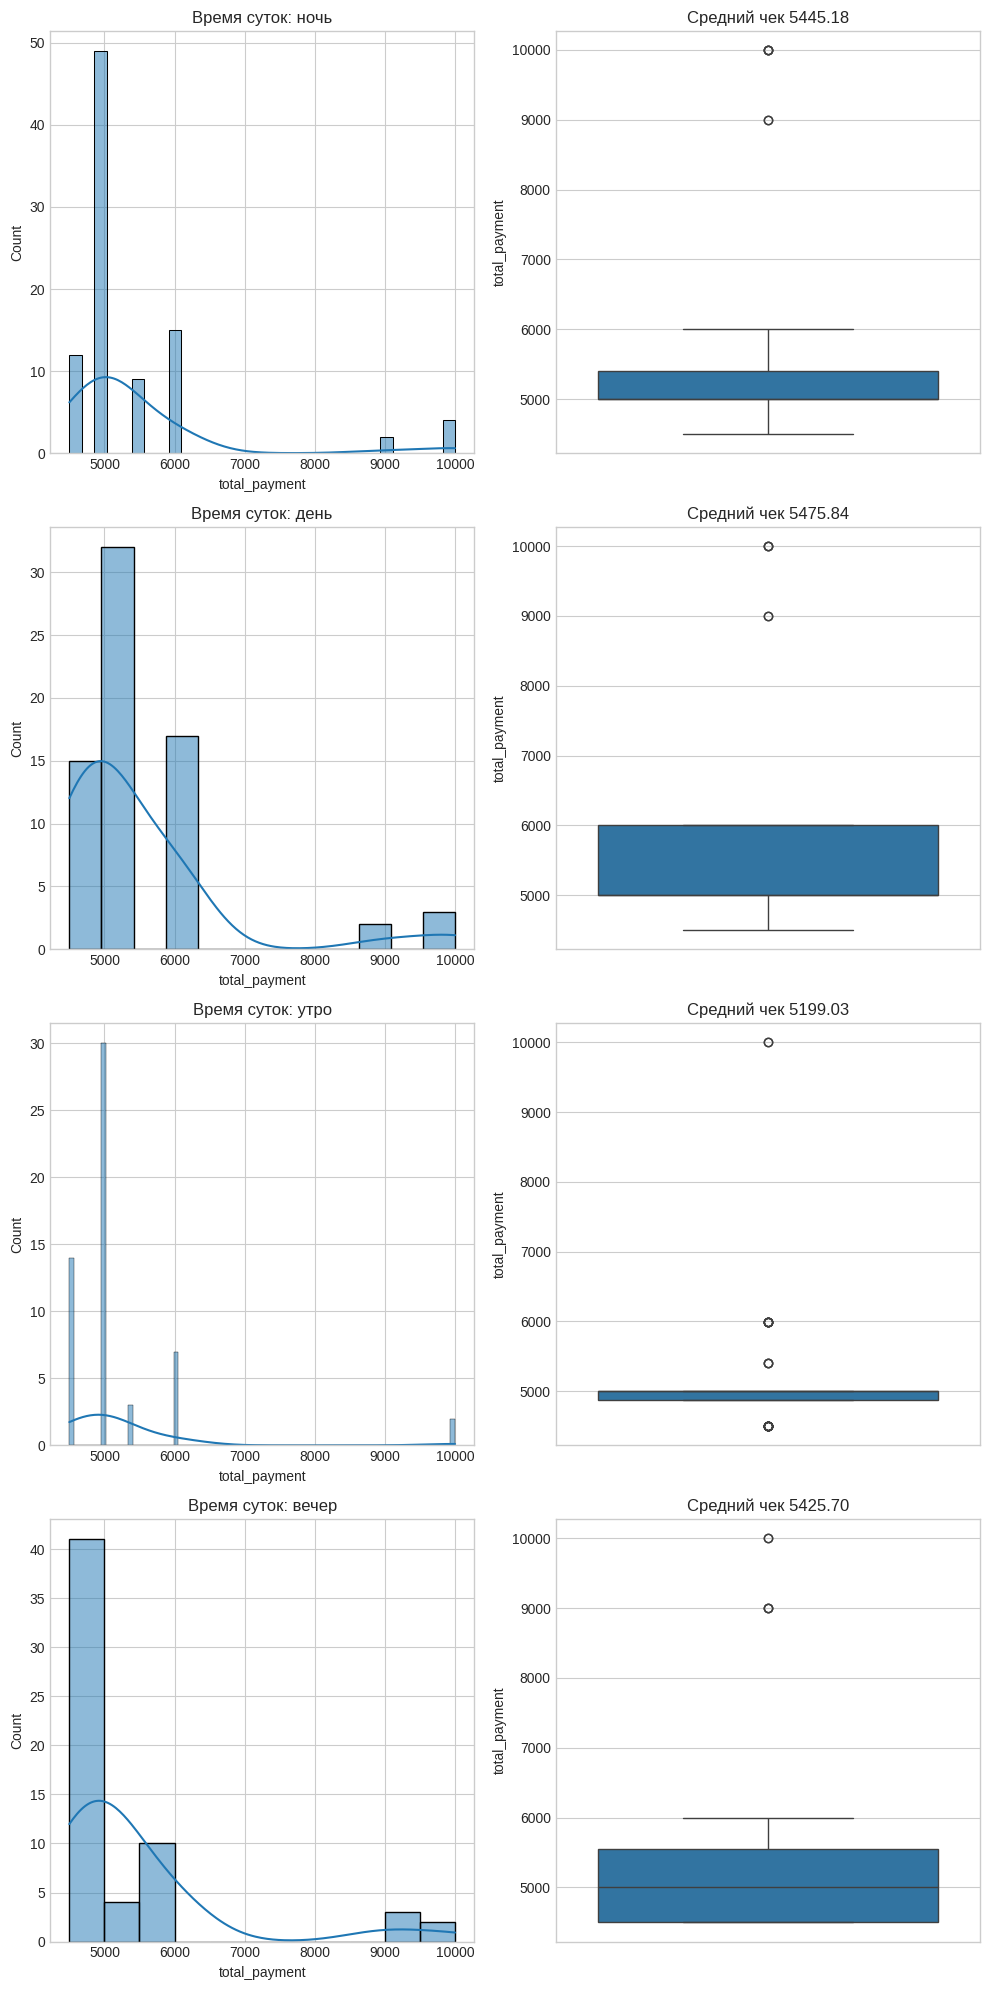

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(10,20))
for i, time_of_day in enumerate(df_payers.time_of_day.unique()):
  data = df_payers[df_payers.time_of_day == time_of_day]
  sns.histplot(data.total_payment, kde=True, ax=ax[i][0])
  sns.boxplot(data.total_payment, ax=ax[i][1])
  ax[i][0].set_title(f"Время суток: {time_of_day}")
  ax[i][1].set_title(f"Средний чек {data.total_payment.mean():.2f}")
plt.tight_layout()
plt.show()

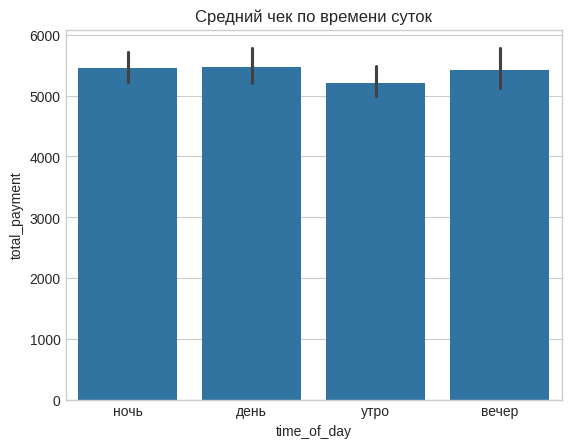

In [ ]:
sns.barplot(data=df_payers, x='time_of_day', y='total_payment', estimator="mean")
plt.title('Средний чек по времени суток')
plt.show()

По графикам средний чек утром вроде как ОТЛИЧАЕТСЯ от остальных. Покажем это математически

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for time_of_day in df_payers.time_of_day.unique():
    data = df_payers[df_payers.time_of_day == time_of_day].total_payment
    stat, p = stats.shapiro(data)
    print(f"{time_of_day}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

ночь: p-value = 0.0000 → Ненормальное
день: p-value = 0.0000 → Ненормальное
утро: p-value = 0.0000 → Ненормальное
вечер: p-value = 0.0000 → Ненормальное


Сравнение происходит по 4 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for time_of_day in df_payers.time_of_day.unique():
    data = df_payers[df_payers.time_of_day == time_of_day]
    groups.append(data.total_payment.values)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.2848 → НЕ влияет (нет оснований отвергнуть H0)


Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, между временем суток НЕТ РАЗЛИЧИЙ в среднем чеке.

#### Есть ли взаимосвязь между продолжительностью сессии с суммой покупок?

Нулевая гипотеза(H0): Между длительностью сессии и суммой покупки НЕТ ВЗАИМОСВЯЗИ. Коэффициент корреляции = 0.

Альтернативная гипотеза(H1): Между длительностью сессии и суммой покупки ЕСТЬ ВЗАИМОСВЯЗЬ. Коэффициент корреляции ≠ 0.

Продолжительность сессии - количественная метрика

Сумма покупки - количественная метрика


Визуализация

In [ ]:
df_payers = df[df['payer'] == 1]

<Axes: xlabel='total_payment', ylabel='session_duration_sec'>

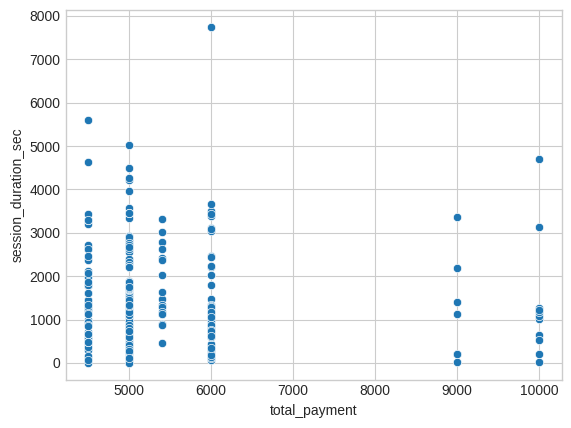

In [ ]:
sns.scatterplot(df_payers, x='total_payment', y='session_duration_sec')

На графике рассеяния видим, что точки не образуют четкой прямой линии.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
stat1, p1 = stats.shapiro(df_payers.total_payment)
print(f"total_payment: p-value = {p1:.4f} → {'Нормальное' if p1 > 0.05 else 'Ненормальное'}")
stat2, p2 = stats.shapiro(df_payers.session_duration_sec)
print(f"session_duration_sec: p-value = {p2:.4f} → {'Нормальное' if p2 > 0.05 else 'Ненормальное'}")

total_payment: p-value = 0.0000 → Ненормальное
session_duration_sec: p-value = 0.0000 → Ненормальное


Сравнение происходит между двумя количетсвенными метриками. Данные распределены не нормально.

Значит выбираем корреляцию Спирмена.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

st, p_value = stats.spearmanr(df_payers.total_payment, df_payers.session_duration_sec)

print(f"Корреляция равна {st:.2f}")

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

Корреляция равна -0.01
p-value = 0.8794 → НЕ влияет (нет оснований отвергнуть H0)


Коэффициент корреляции st = -0.01 практически равен нулю, что указывает на полное отсутствие связи между переменными.

Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, между длительностью сессии и суммой покупки НЕТ ВЗАИМОСВЯЗИ.

#### Влияет ли время суток на количество покупок в день?

Нулевая гипотеза (H0): Время суток НЕ ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день одинаково независимо от времени суток.

Альтернативная гипотеза (H1): Время суток ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день различается в зависимости от времени суток.

Количество покупок в день - количественная метрика

Время суток - номинальная метрика

Для начала сгруппируем данные по дате покупки и времени суток.

Если в какой-то день в определенное время покупок не было, то ставим 0.

In [ ]:
df_payers = df[df['payer'] == 1]

df_payers.loc[:, 'order_dt'] = df_payers['order_dt'].dt.date

daily_purchases = df_payers.groupby(['order_dt', 'time_of_day']).size().reset_index(name='purchases_per_day')

times_of_day = daily_purchases.time_of_day.unique()
dates = daily_purchases.order_dt.unique()

full_index = pd.MultiIndex.from_product(
    [ times_of_day, dates],
    names=['time_of_day', 'order_dt']
)

daily_purchases_full = (
    daily_purchases
    .set_index(['time_of_day', 'order_dt'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

Визуализация

<Axes: >

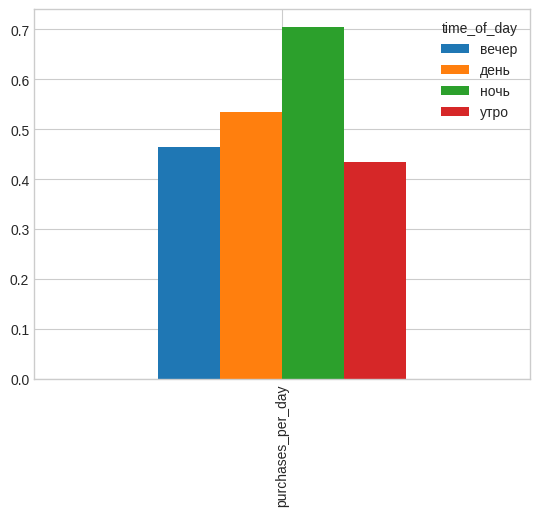

In [ ]:
pivot_mean = daily_purchases_full.pivot_table(
    values='purchases_per_day',
    columns='time_of_day',
    aggfunc='mean'
)
pivot_mean.plot(kind='bar')


Визуально заметно, что ночью покупок больше

Однако надо проверить и математически.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for time_of_day in daily_purchases_full.time_of_day.unique():
    data = daily_purchases_full[daily_purchases_full.time_of_day == time_of_day].purchases_per_day
    stat, p = stats.shapiro(data)
    print(f"{time_of_day}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

ночь: p-value = 0.0000 → Ненормальное
день: p-value = 0.0000 → Ненормальное
утро: p-value = 0.0000 → Ненормальное
вечер: p-value = 0.0000 → Ненормальное


Сравнение происходит по 4 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for time_of_day in daily_purchases_full.time_of_day.unique():
    time_of_day_purchases = daily_purchases_full[daily_purchases_full.time_of_day == time_of_day].purchases_per_day.values
    groups.append(time_of_day_purchases)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.0117 → ВЛИЯЕТ (отвергаем H0)


Нет оснований принять нулевую гипотезу. Принимается альтернативная.

Таким образом, время суток ВЛИЯЕТ на количество покупок в день.

#### Влияет ли день недели на количество покупок в день?

Нулевая гипотеза (H0): День недели НЕ ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день одинаково независимо от дня недели.

Альтернативная гипотеза (H1): День недели ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день различается в зависимости от дня недели.

Количество покупок в день - количественная метрика

День недели - номинальная метрика

Для начала сгруппируем данные по дате покупки и дню недели.

Если в какой-то день в определенный день недели покупок не было, то ставим 0.

In [ ]:
df_payers = df[df['payer'] == 1]

df_payers.loc[:, 'order_dt'] = df_payers['order_dt'].dt.date

daily_purchases = df_payers.groupby(['order_dt', 'day']).size().reset_index(name='purchases_per_day')

days = daily_purchases.day.unique()
dates = daily_purchases.order_dt.unique()

full_index = pd.MultiIndex.from_product(
    [ days, dates],
    names=['day', 'order_dt']
)

daily_purchases_full = (
    daily_purchases
    .set_index(['day', 'order_dt'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

Визуализация

<Axes: >

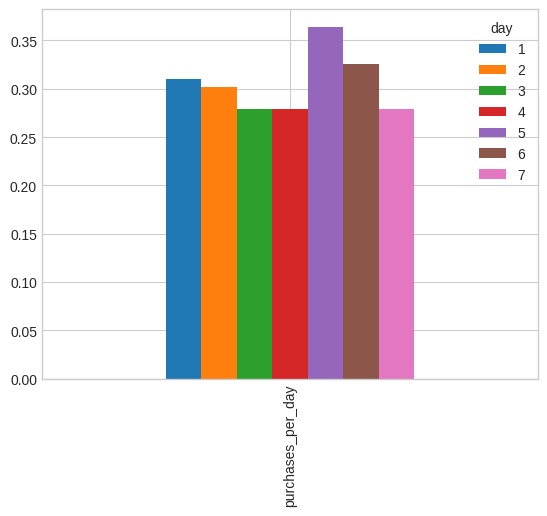

In [ ]:
pivot_mean = daily_purchases_full.pivot_table(
    values='purchases_per_day',
    columns='day',
    aggfunc='mean'
)
pivot_mean.plot(kind='bar')

Визуально заметно, что по значениям особо различий нет

Однако надо проверить и математически.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for day in daily_purchases_full.day.unique():
    data = daily_purchases_full[daily_purchases_full.day == day].purchases_per_day
    stat, p = stats.shapiro(data)
    print(f"{day}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

3: p-value = 0.0000 → Ненормальное
1: p-value = 0.0000 → Ненормальное
2: p-value = 0.0000 → Ненормальное
4: p-value = 0.0000 → Ненормальное
7: p-value = 0.0000 → Ненормальное
5: p-value = 0.0000 → Ненормальное
6: p-value = 0.0000 → Ненормальное


Сравнение происходит по 7 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for day in daily_purchases_full.day.unique():
    day_purchases = daily_purchases_full[daily_purchases_full.day == day].purchases_per_day.values
    groups.append(day_purchases)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.9098 → НЕ влияет (нет оснований отвергнуть H0)


Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, день недели НЕ ВЛИЯЕТ на количество покупок в день.

#### Влияет ли месяц покупки на количество покупок в день?

Нулевая гипотеза (H0): Месяц покупки НЕ ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день одинаково независимо от месяца покупки.

Альтернативная гипотеза (H1): Месяц покупки ВЛИЯЕТ на количество покупок в день. Среднее количество покупок в день различается в зависимости от месяца покупки.

Количество покупок в день - количественная метрика

Месяц покупки - номинальная метрика

Для начала сгруппируем данные по дате покупки и месяцу покупки.

Если в какой-то день в определенный месяц покупок не было, то ставим 0.

In [ ]:
df_payers = df[df['payer'] == 1]

df_payers.loc[:, 'order_dt'] = df_payers['order_dt'].dt.date

daily_purchases = df_payers.groupby(['order_dt', 'month']).size().reset_index(name='purchases_per_day')

months = daily_purchases.month.unique()
dates = daily_purchases.order_dt.unique()

full_index = pd.MultiIndex.from_product(
    [months, dates],
    names=['month', 'order_dt']
)

daily_purchases_full = (
    daily_purchases
    .set_index(['month', 'order_dt'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

Визуализация

<Axes: >

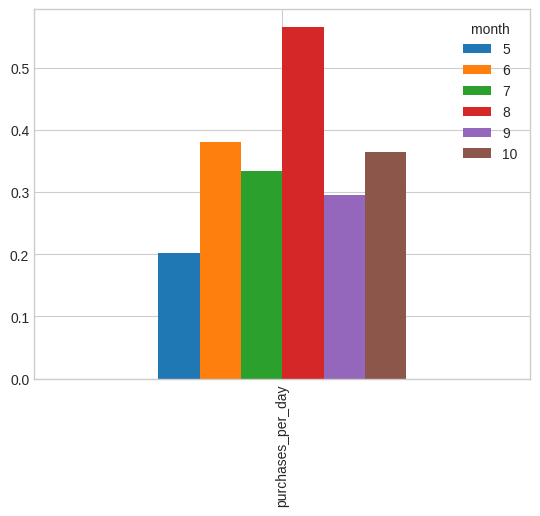

In [ ]:
pivot_mean = daily_purchases_full.pivot_table(
    values='purchases_per_day',
    columns='month',
    aggfunc='mean'
)
pivot_mean.plot(kind='bar')

Визуально заметно, что 8й месяц принёс больше покупателей.

Однако надо проверить и математически.

Проверим на нормальное распределение по методу Шапиро.


In [ ]:
for month in daily_purchases_full.month.unique():
    data = daily_purchases_full[daily_purchases_full.month == month].purchases_per_day
    stat, p = stats.shapiro(data)
    print(f"{month}: p-value = {p:.4f} → {'Нормальное' if p > 0.05 else 'Ненормальное'}")

5: p-value = 0.0000 → Ненормальное
6: p-value = 0.0000 → Ненормальное
7: p-value = 0.0000 → Ненормальное
8: p-value = 0.0000 → Ненормальное
9: p-value = 0.0000 → Ненормальное
10: p-value = 0.0000 → Ненормальное


Сравнение происходит по 6 группам. Данные распределены не нормально.

Значит выбираем критерий Краскела-Уоллеса.

Уровень значимости α = 0,05 (стандартное значение для бизнес-аналитики).



In [ ]:
alpha = 0.05

groups = []
for month in daily_purchases_full.month.unique():
    month_purchases = daily_purchases_full[daily_purchases_full.month == month].purchases_per_day.values
    groups.append(month_purchases)

h_stat, p_value = stats.kruskal(*groups)

print(f"p-value = {p_value:.4f} → ", end="")
if p_value < alpha:
    print("ВЛИЯЕТ (отвергаем H0)")
else:
    print("НЕ влияет (нет оснований отвергнуть H0)")

p-value = 0.5953 → НЕ влияет (нет оснований отвергнуть H0)


Нет оснований отвергнуть нулевую гипотезу, значит остаёмся при ней.

Таким образом, месяц покупки НЕ ВЛИЯЕТ на количество покупок в день.

## 5. Прогноз `total_payment`

Здесь пробую предсказать `total_payment` по данным с помощью линейной регрессии.


### 5.1 Загрузка Данных

In [ ]:
data_path = '/content/drive/MyDrive/анализ данных/ecom_refined.csv'
target = "total_payment"
seed = 42
test_share = 0.2

raw_data = pd.read_csv(data_path)
raw_data = raw_data.drop(columns=["Unnamed: 0"])

display(raw_data.head())
print(f"Размер датасета: {raw_data.shape}")
print("Столбцы в данных:")
print(raw_data.columns.tolist())


,user_id,region,device,channel,session_start,session_end,session_duration_sec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_payment,time_of_day,payer
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.000000,2025-05-01,5,3,0,2025-05-01 00:06:40,"9,999.000000",Mobile payments,0.000000,"9,999.000000",ночь,1
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.000000,2025-05-01,5,3,7,NaN,NaN,NaN,NaN,NaN,утро,0
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.000000,2025-05-01,5,3,4,NaN,NaN,NaN,NaN,NaN,ночь,0
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.000000,2025-05-01,5,3,18,NaN,NaN,NaN,NaN,NaN,вечер,0
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.000000,2025-05-02,5,4,14,NaN,NaN,NaN,NaN,NaN,день,0


Размер датасета: (1002, 18)
Столбцы в данных:
['user_id', 'region', 'device', 'channel', 'session_start', 'session_end', 'session_duration_sec', 'session_date', 'month', 'day', 'hour_of_day', 'order_dt', 'revenue', 'payment_type', 'promo_code', 'total_payment', 'time_of_day', 'payer']


### 5.2 Подготовка признаков

Тут решил оставить `region`, `device`, `channel`, `month`, `day` и `hour_of_day`. Из временных признаков беру только `month`, `day` и `hour_of_day`.
При этом `revenue`, `promo_code`, `payer` (постфактум-признаки, мы не можем сказать заранее, платил ли человек вообще). Это почти готовый ответ, и тогда модель будет не учиться, а подглядывать.

In [ ]:
df2 = raw_data.copy()
df2[target] = df2[target].fillna(0.0)
df2["is_purchase"] = (df2[target] > 0).astype(int)

feature_cols = [
    "region",
    "device",
    "channel",
    "month",
    "day",
    "hour_of_day",
]

cat_cols = ["region", "device", "channel", "month"]
num_cols = ["day", "hour_of_day"]

print("Для модели беру такие признаки:")
print(feature_cols)
print(f"Категориальные: {cat_cols}")
print(f"Числовые: {num_cols}")
print("Из дат оставляю только month, day и hour_of_day.")
print("revenue, promo_code и payer не использую.")


Для модели беру такие признаки:
['region', 'device', 'channel', 'month', 'day', 'hour_of_day']
Категориальные: ['region', 'device', 'channel', 'month']
Числовые: ['day', 'hour_of_day']
Из дат оставляю только month, day и hour_of_day.
revenue, promo_code и payer не использую.


### 5.3 Обучение модели

Здесь я обучал модель `LinearRegression`.

Данные делю на train и test в пропорции 80/20.


In [ ]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def make_model():
    cat_pipe = Pipeline(
        steps=[
            ("fill_missing", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    num_transformer = SimpleImputer(strategy="median")

    tmp = ColumnTransformer(
        transformers=[
            ("categorical", cat_pipe, cat_cols),
            ("numeric", num_transformer, num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return Pipeline(
        steps=[
            ("preprocessor", tmp),
            ("model", LinearRegression()),
        ]
    )


X = df2[feature_cols].copy()
y = df2[target].copy()
purchase_flag = df2["is_purchase"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_share,
    random_state=seed,
    stratify=purchase_flag,
)

model = make_model()
model.fit(X_train, y_train)

train_pred = np.clip(model.predict(X_train), 0, None)
test_pred = np.clip(model.predict(X_test), 0, None)

train_scores = get_metrics(y_train, train_pred)
test_scores = get_metrics(y_test, test_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
rows = []
for train_idx, val_idx in cv.split(X, purchase_flag):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    tmp_model = make_model()
    tmp_model.fit(X_tr, y_tr)
    tmp_pred = np.clip(tmp_model.predict(X_val), 0, None)
    rows.append(get_metrics(y_val, tmp_pred))

cv_report = pd.DataFrame(rows)

metrics_table = pd.DataFrame(
    {
        "Где смотрим": ["train", "test", "CV в среднем"],
        "MAE": [train_scores["MAE"], test_scores["MAE"], cv_report["MAE"].mean()],
        "RMSE": [train_scores["RMSE"], test_scores["RMSE"], cv_report["RMSE"].mean()],
        "R2": [train_scores["R2"], test_scores["R2"], cv_report["R2"].mean()],
    }
)

display(metrics_table)
print(
    "По фолдам разброс такой: "
    f"MAE ± {cv_report['MAE'].std():.2f}, "
    f"RMSE ± {cv_report['RMSE'].std():.2f}, "
    f"R2 ± {cv_report['R2'].std():.4f}"
)


,Где смотрим,MAE,RMSE,R2
0,train,"2,071.649970","2,434.556303",0.032866
1,test,"2,136.042910","2,593.814062",-0.018161
2,CV в среднем,"2,122.461596","2,501.798156",-0.005659


По фолдам разброс такой: MAE ± 48.74, RMSE ± 76.58, R2 ± 0.0269


Метрики слабые, но сделать их лучше пока не получится, данных мало

### 5.4 Анализ результатов

В конце смотрю не только на метрики, но и на коэффициенты и графики. Хочется понять, на что модель вообще реагирует.
В итоге модель что-то да ловит, но по качеству видно, что данных мало. До нормального прогноза тут еще слишком уж мало данных.


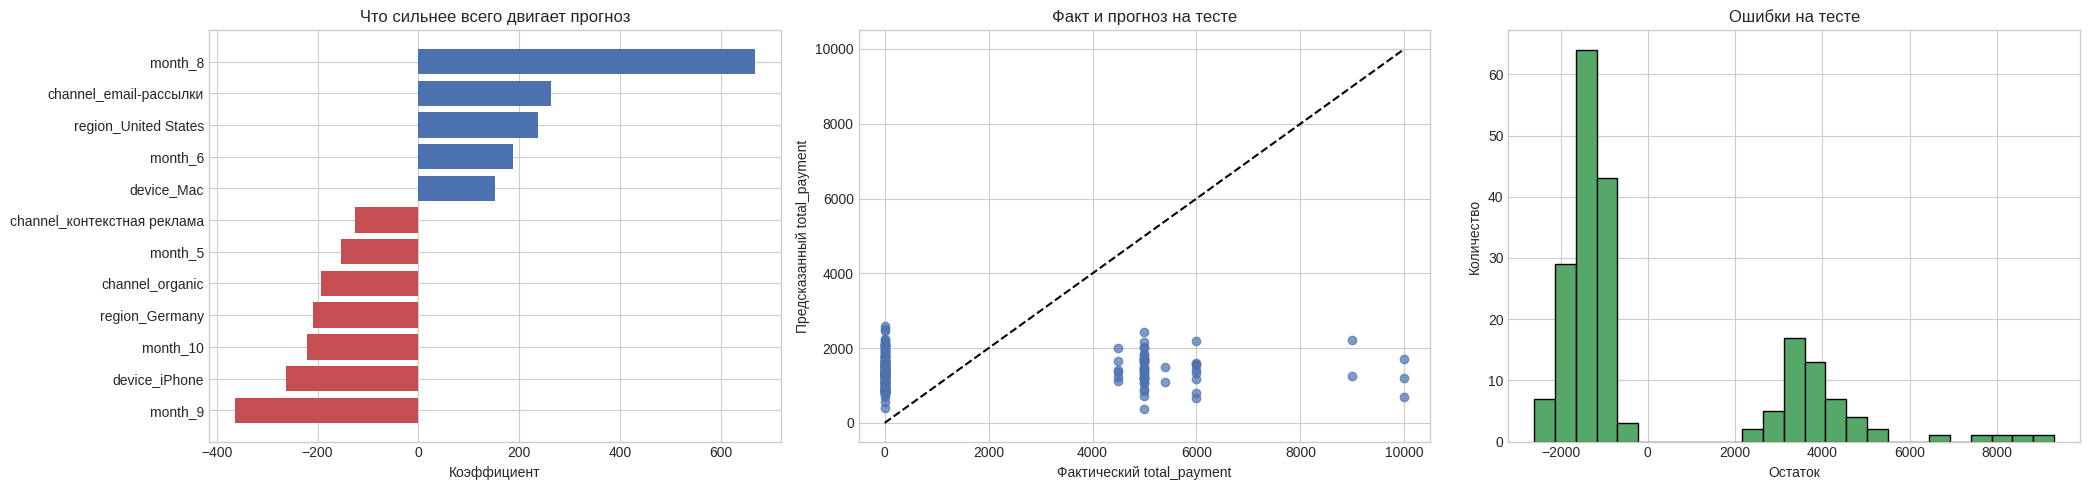

,coefficient
month_8,667.206138
month_9,-363.773915
device_iPhone,-262.562822
channel_email-рассылки,262.533074
region_United States,237.398827
month_10,-220.261382
region_Germany,-209.594013
channel_organic,-192.457915
month_6,188.603590
month_5,-153.457130


Самый большой промах на тесте: 9310.173118


In [ ]:
coef_table = pd.Series(
    model.named_steps["model"].coef_,
    index=model.named_steps["preprocessor"].get_feature_names_out(),
    name="coefficient",
).sort_values(key=np.abs, ascending=False)

errors = y_test - test_pred
plot_min = min(y_test.min(), test_pred.min())
plot_max = max(y_test.max(), test_pred.max())

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

tmp = coef_table.head(12).sort_values()
bar_colors = ["#c44e52" if value < 0 else "#4c72b0" for value in tmp.values]
axes[0].barh(tmp.index, tmp.values, color=bar_colors)
axes[0].set_title("Что сильнее всего двигает прогноз")
axes[0].set_xlabel("Коэффициент")

axes[1].scatter(y_test, test_pred, alpha=0.7, color="#4c72b0")
axes[1].plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black")
axes[1].set_title("Факт и прогноз на тесте")
axes[1].set_xlabel("Фактический total_payment")
axes[1].set_ylabel("Предсказанный total_payment")

axes[2].hist(errors, bins=25, color="#55a868", edgecolor="black")
axes[2].set_title("Ошибки на тесте")
axes[2].set_xlabel("Остаток")
axes[2].set_ylabel("Количество")

plt.tight_layout()
plt.show()

display(coef_table.head(12).to_frame())

worst_error = np.abs(errors).max()
print(f"Самый большой промах на тесте: {worst_error:.6f}")

### 5.5 Итоговый вывод

По итогу метрики показывают, что модель слабая. Потому что на тесте вышло `MAE ≈ 2136.04`, `RMSE ≈ 2593.81`, `R2 ≈ -0.0182`, а средний `R2` по кросс-валидации вообще почти нулевой: `-0.0057`.

Модель что-то понимает, но всё равно очень не точная. Просто напросто данных, которые сейчас даны - очень мало. Поэтому, что бы модель была точная, то хотелось бы либо большего количества таких данных, либо других данных, по типу истории покупок, поведения пользователя и так далее.

Ну и честно говоря, R2 на уровне нуля - это уже совсем слабо.